In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import constraints
from torch.func import vmap

In [2]:
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, TraceEnum_ELBO, config_enumerate, infer_discrete
from pyro.ops.indexing import Vindex
from pyro import poutine

In [3]:
import numpy as np
import math
from itertools import product, accumulate
import einops
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns
import umap  

In [4]:
def generalized_einsum(tensor_a, tensor_b):
    # Get shapes
    shape_a = tensor_a.shape  # e.g., (n, a1, a2, a3, a4, ...)
    shape_b = tensor_b.shape  # e.g., (..., k) = (a4, a3, a2, a1, k)
    
    # Extract n (first dimension of A)
    n = shape_a[0]
    
    # Extract additional dimensions from A (excluding n)
    dims_a = list(shape_a[1:])  # e.g., [a1, a2, a3, a4]
    
    # Extract dimensions from B (excluding k)
    dims_b = list(shape_b[:-1])  # e.g., [a4, a3, a2, a1]
    k = shape_b[-1]
    
    # Validate that B's dimensions (excluding k) are the reverse of A's (excluding n)
    if dims_a != dims_b[::-1]:
        raise ValueError(f"Dimensions {dims_a} and {dims_b} are not compatible (must be reverse order)")
    
    # Create dimension labels
    # Use unique letters for each dimension (e.g., i, j, k, l for a1, a2, a3, a4)
    dim_labels = [chr(105 + i) for i in range(len(dims_a))]  # e.g., ['i', 'j', 'k', 'l']
    
    # Pattern for A: n followed by additional dims
    pattern_a = f"a {' '.join(dim_labels)}"  # e.g., "n i j k l"
    
    # Pattern for B: reversed additional dims followed by k
    pattern_b = f"{' '.join(dim_labels[::-1])} z"  # e.g., "l k j i k"
    
    # Output pattern: n k
    pattern_out = "a z"
    
    # Full einsum pattern
    pattern = f"{pattern_a}, {pattern_b} -> {pattern_out}"  # e.g., "n i j k l, l k j i k -> n k"
    
    # Perform einsum
    return einops.einsum(tensor_a, tensor_b, pattern)

In [5]:
def mix_weights(beta):
    # Compute cumulative product of (1 - beta) along the last dimension
    beta1m_cumprod = (1 - beta).cumprod(dim=-1)
    # Pad beta with a 1 at the end of the last dimension
    beta_padded = F.pad(beta, (0, 1), value=1)
    # Pad beta1m_cumprod with a 1 at the start of the last dimension
    beta1m_cumprod_padded = F.pad(beta1m_cumprod, (1, 0), value=1)
    # Element-wise multiplication
    weight = beta_padded * beta1m_cumprod_padded
    rlt = torch.max(weight, torch.tensor(1e-6, device=beta.device))
    rlt = rlt/rlt.sum(dim=-1, keepdim=True)
    # return F.softmax(beta_padded * beta1m_cumprod_padded, dim=-1)
    return rlt
    

In [6]:
@config_enumerate
def model(data, struct_upbd, vocab_size, device):
    # # Initialize parameters
    param_dims = list(struct_upbd.values())
    param_dims.reverse()
    
    struct_params = {}
    # dimension: number of mixture
    struct_params["alpha0"] = pyro.param("model_alpha0", torch.rand(1, device=device) , constraint=constraints.positive).expand(param_dims[-1:])
    # dimension: number of mixture
    struct_params["alpha1"] = pyro.param("model_alpha1", torch.rand(1, device=device) , constraint=constraints.positive).expand(param_dims[-1:])
    
    for i in range(2, len(struct_upbd)+1, 1):
        # dimension: level i category * level i-1 category * ... * level 1 category * number of mixture
        struct_params[f"alpha{i}"] = pyro.param(f"model_alpha{i}", torch.rand(param_dims[-i:-1], device=device) , constraint=constraints.positive).unsqueeze(-1).expand(param_dims[-i:])
    # dimension: number of mixture * vocabulary size
    gen_params = pyro.param("model_phi_u", torch.distributions.Dirichlet(torch.ones(vocab_size, device=device)).sample((struct_upbd["G0"], )), constraint=constraints.simplex)
    # dimension: number of mixture * 1
    reg_params_mu = pyro.param("model_phi_y_mu", torch.distributions.Normal(loc = torch.tensor(0.0, device=device), scale = torch.tensor(1.0, device=device)).sample((struct_upbd["G0"], )))
    # dimension: number of mixture * 1
    reg_params_sigma = pyro.param("model_phi_y_sigma", torch.distributions.Uniform(torch.tensor(1e-3, device=device), torch.tensor(1.0, device=device)).sample((struct_upbd["G0"], )), constraint=constraints.positive)

    struct_weights = {}
    # dimension: number of mixture
    beta_0 = pyro.sample("G0", dist.Beta(torch.ones([struct_upbd["G0"]], device=device), struct_params["alpha0"]).to_event(1))
    # dimension: number of mixture
    struct_weights["G0"] = mix_weights(beta_0)[..., :-1]
    for level in range(1, len(struct_upbd), 1):
        struct_weights["G0"] = struct_weights["G0"].flatten()
        # dimension: level level category * level level-1 category * ... * level 1 category * number of mixture
        param_alpha = struct_params[f"alpha{level}"]*struct_weights[f"G{level-1}"]
        # print(struct_params[f"alpha{level}"].shape, struct_weights[f"G{level-1}"].shape)
        # print(f"level {level}, alpha shape {param_alpha.shape}")

        param_beta = struct_params[f"alpha{level}"]*(1 - struct_weights[f"G{level-1}"].cumsum(-1))
        with pyro.plate(f"LoG{level}", struct_upbd[f"G{level}"]):
            # dimension: level level+1 category * level level category * level level-1 category * ... * level 1 category * number of mixture
            beta = pyro.sample(f"G{level}", dist.Beta(param_alpha.unsqueeze(0).expand(param_dims[-level-1:]), param_beta.unsqueeze(0).expand(param_dims[-level-1:])).to_event(level))
        # dimension: level level+1 category * level level category * level level-1 category * ... * level 1 category * number of mixture
        # print(f"next level {beta.shape}")
        struct_weights[f"G{level}"] = mix_weights(beta)[..., :-1]

    assign_prior = {}
    # dimension: number of level - 1
    etas = torch.distributions.Gamma(torch.tensor(1.0, device=device), torch.tensor(1.0, device=device)).sample((len(struct_upbd)-1,))
    for level in range(1, len(struct_upbd), 1):
        params_shape = param_dims[-level-1:-1]
        params_shape.reverse()
        # dimension: level 1 category * level 2 category * ... * level level category
        assign_prior[f"LoZ{level}"] = pyro.param(f"model_LoZ{level}", torch.distributions.Dirichlet(torch.ones(struct_upbd[f"G{level}"], device=device)).sample(params_shape[:-1]), constraint=constraints.simplex)

    feature = data[0].to(device)
    if data[1] is not None:
        label = data[1].to(device)
    else:
        label = data[1]
    N = feature.shape[0]
    M = feature.shape[1]

    assigned_zs = [torch.tensor([0], device=device).expand(N)]
    
    with pyro.plate("Data", N):
        for level in range(1, len(struct_upbd), 1):
            parent_z = assigned_zs[-1]
            param = assign_prior[f"LoZ{level}"].unsqueeze(0)[assigned_zs[:]]
            assigned_zs.append(pyro.sample(f"z{level}", dist.Categorical(param)))

        assigned_zs.reverse()
        weights_prior = struct_weights[f"G{len(struct_upbd)-1}"][assigned_zs[:-1]]
        concentrate = struct_params[f"alpha{len(struct_upbd)}"][assigned_zs[:-1]]

        topic_dist = pyro.sample("g", dist.Dirichlet(concentrate*weights_prior))
        reg_dists = dist.Normal(reg_params_mu.expand(N, struct_upbd["G0"]), reg_params_sigma.expand(N, struct_upbd["G0"]))
        reg_mix = dist.Categorical(topic_dist)
        pyro.sample("y", dist.MixtureSameFamily(reg_mix, reg_dists), obs=label)
        # print("topic", topic_dist.shape)

        topic_over_docs = topic_dist.unsqueeze(1).expand(-1, M, -1)
        z = pyro.sample(f"z{len(struct_upbd)}", dist.Categorical(probs=topic_over_docs).to_event(1))
        # print(z.shape)

        # Sample observed words from selected topics
        word_dists = gen_params[z]  # shape: (D, N, V)
        # print(word_dists.shape)
        pyro.sample("u", dist.Multinomial(1, probs=word_dists).to_event(1), obs=feature)

In [7]:
def guide(data, struc_upbd, vocab_size, device):
    # # Initialize parameters
    param_dims = list(struct_upbd.values())
    param_dims.reverse()

    init = torch.rand(struct_upbd["G0"])
    init = init.to(device).clone().detach().requires_grad_() 
    q_beta_0_alpha = pyro.param("guide_beta_0_alpha", init, constraint=constraints.positive)
    init = torch.rand(struct_upbd["G0"])
    init = init.to(device).clone().detach().requires_grad_() 
    q_beta_0_beta = pyro.param("guide_beta_0_beta", init, constraint=constraints.positive)
    beta_0 = pyro.sample("G0", dist.Beta(q_beta_0_alpha, q_beta_0_beta).to_event(1))
    for level in range(1, len(struct_upbd), 1):
        init = torch.rand(param_dims[-level:])
        init = init.to(device).clone().detach().requires_grad_() 
        param_alpha = pyro.param(f"guide_beta_{level}_alpha", init, constraint=constraints.positive)
        init = torch.rand(param_dims[-level:])
        init = init.to(device).clone().detach().requires_grad_() 
        param_beta = pyro.param(f"guide_beta_{level}_beta", init, constraint=constraints.positive)
        with pyro.plate(f"LoG{level}", struct_upbd[f"G{level}"]):
            beta = pyro.sample(f"G{level}", dist.Beta(param_alpha.unsqueeze(0).expand(param_dims[-level-1:]), param_beta.unsqueeze(0).expand(param_dims[-level-1:])).to_event(level))
        
    feature = data[0].to(device)
    if (data[1] is not None):
        label = data[1].to(device)
    else:
        label = data[1]
    N = feature.shape[0]
    M = feature.shape[1]

    # Guide only for the continuous latent variable: g
    # Variational parameters for Dirichlet over topic_dist
    g_concentration = pyro.param("guide_g_concentration", torch.ones((N, struct_upbd["G0"]), device=device),
                                 constraint=constraints.positive)

    
    with pyro.plate("Data", N):
        # for level in range(1, len(struct_upbd), 1):
        #     z_param = pyro.param(f"z_param{level}", torch.rand((N, struct_upbd[f"G{level}"]), device=device), constraint=constraints.simplex)
        #     pyro.sample(f"z{level}", dist.Categorical(z_param))
        pyro.sample("g", dist.Dirichlet(g_concentration))


In [8]:
def set_requires_grad_by_prefix(prefix, requires_grad):
    for name, param in pyro.get_param_store().items():
        if name.startswith(prefix) and param.is_leaf:
            param.requires_grad = requires_grad

In [9]:
def generate_hierarchical_mixture_data(struct_upbd,
    N_per_base=20, M=30, V=100,  # N_per_base: number of samples per base category
    seed=0
):

    num_super = struct_upbd["G1"]
    num_base_per_super = struct_upbd["G2"]
    num_components = struct_upbd["G0"]

    total_super = num_super
    total_base = num_super * num_base_per_super
    total_data = total_base * N_per_base

    # Shared components
    word_block_size = int(V/num_components)
    block_word_dists = torch.distributions.Dirichlet(0.01 * torch.ones(word_block_size)).sample((num_components,))
    word_dists = torch.zeros(num_components, V)
    # Construct index tensor for column positions in B
    rows = torch.arange(num_components).unsqueeze(1).repeat(1, word_block_size)  # shape (5, 4)
    cols =  word_block_size * rows + torch.arange(word_block_size)  # shape (5, 4)
    word_dists[rows, cols] = block_word_dists
    
    y_means = torch.linspace(-3, 3, steps=num_components)
    y_stds = 0.1 + 0.1 * torch.rand(num_components)

    # Create per-base-category mixture weights over the 10 shared components

    super_cat_block = int(num_components / total_super)
    super_mixture_weights = torch.zeros((total_super, num_components))
    rows = torch.arange(total_super).unsqueeze(1).repeat(1, super_cat_block)  # shape (5, 4)
    cols =  super_cat_block * rows + torch.arange(super_cat_block)  # shape (5, 4)
    super_mixture_weights[rows, cols] = 1./super_cat_block
    
    child_cat_block = int(num_components / total_base)
    child_mixture_weights = torch.zeros((total_base, num_components))
    rows = torch.arange(total_base).unsqueeze(1).repeat(1, child_cat_block)  # shape (5, 4)
    cols =  child_cat_block * rows + torch.arange(child_cat_block)  # shape (5, 4)
    child_mixture_weights[rows, cols] = 1./child_cat_block
    child_mixture_weights = child_mixture_weights.view(num_super, num_base_per_super, num_components)
    child_mixture_weights = child_mixture_weights.transpose(0, 1)
    
    print("super", super_mixture_weights.shape)
    print(super_mixture_weights)
    print("child", child_mixture_weights.shape)
    print(child_mixture_weights)

    x_data = torch.zeros((total_data, M, V))
    y_data = torch.zeros(total_data)
    labels_super = torch.zeros(total_data, dtype=torch.long)
    labels_base = torch.zeros(total_data, dtype=torch.long)

    idx = 0
    for super_id in range(num_super):
        for base_offset in range(num_base_per_super):
            base_id = super_id * num_base_per_super + base_offset
            weights = child_mixture_weights[base_offset, super_id]

            for _ in range(N_per_base):
                # Choose a component based on mixture weights
                comp_id = torch.multinomial(weights, 1).item()

                # Generate bag-of-words document
                word_ids = torch.multinomial(word_dists[comp_id], M, replacement=True)
                x_data[idx] = F.one_hot(word_ids, num_classes=V).float()

                # Generate regression label
                y_data[idx] = torch.normal(mean=y_means[comp_id], std=y_stds[comp_id], size=(1,))

                labels_super[idx] = super_id
                labels_base[idx] = base_id
                idx += 1

    return {
        "x": x_data,                  # (total_data, M, V)
        "y": y_data,                  # (total_data,)
        "super_labels": labels_super,  # (total_data,)
        "base_labels": labels_base,    # (total_data,)
        "word_dists": word_dists,      # (num_components, V)
        "super_mix_weights": super_mixture_weights,
        "child_mix_weights": child_mixture_weights     # (num_super*num_base_per_super, 
        
    }


In [10]:
struct_upbd = {"G0": 6, "G1": 2, "G2": 3}
data = generate_hierarchical_mixture_data(struct_upbd)
# Aggregate bag-of-words sequences by summing over M dimension
  # (total_data, V)
x_agg = data["x"].sum(dim=1)
vocab_size = data["x"].shape[-1]

super torch.Size([2, 6])
tensor([[0.3333, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.3333, 0.3333, 0.3333]])
child torch.Size([3, 2, 6])
tensor([[[1., 0., 0., 0., 0., 0.],
         [0., 0., 0., 1., 0., 0.]],

        [[0., 1., 0., 0., 0., 0.],
         [0., 0., 0., 0., 1., 0.]],

        [[0., 0., 1., 0., 0., 0.],
         [0., 0., 0., 0., 0., 1.]]])


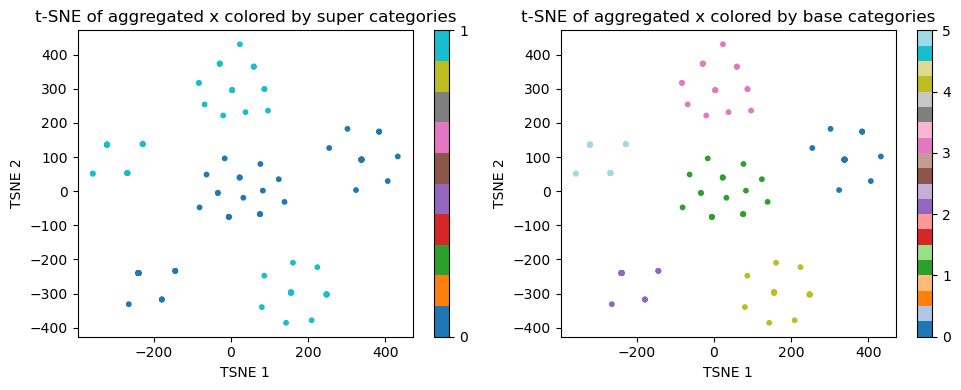

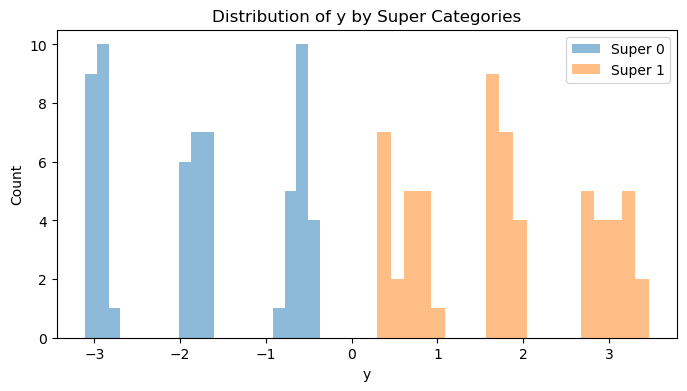

In [11]:
# Run t-SNE
tsne = TSNE(n_components=2, random_state=0)
x_embedded = tsne.fit_transform(x_agg.numpy())

# Plot t-SNE colored by super categories
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
scatter = plt.scatter(x_embedded[:, 0], x_embedded[:, 1], c=data["super_labels"], cmap="tab10", s=10)
plt.colorbar(scatter, ticks=range(6))
plt.title("t-SNE of aggregated x colored by super categories")
plt.xlabel("TSNE 1")
plt.ylabel("TSNE 2")

# Plot t-SNE colored by base categories
plt.subplot(1, 2, 2)
scatter = plt.scatter(x_embedded[:, 0], x_embedded[:, 1], c=data["base_labels"], cmap="tab20", s=10)
plt.colorbar(scatter, ticks=range(18))
plt.title("t-SNE of aggregated x colored by base categories")
plt.xlabel("TSNE 1")
plt.ylabel("TSNE 2")

plt.tight_layout()
plt.show()

# Plot distribution of y by super categories
plt.figure(figsize=(8, 4))
for super_id in range(struct_upbd["G1"]):
    y_vals = data["y"][data["super_labels"] == super_id].numpy()
    plt.hist(y_vals, bins=20, alpha=0.5, label=f"Super {super_id}")

plt.title("Distribution of y by Super Categories")
plt.xlabel("y")
plt.ylabel("Count")
plt.legend()
plt.show()


/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


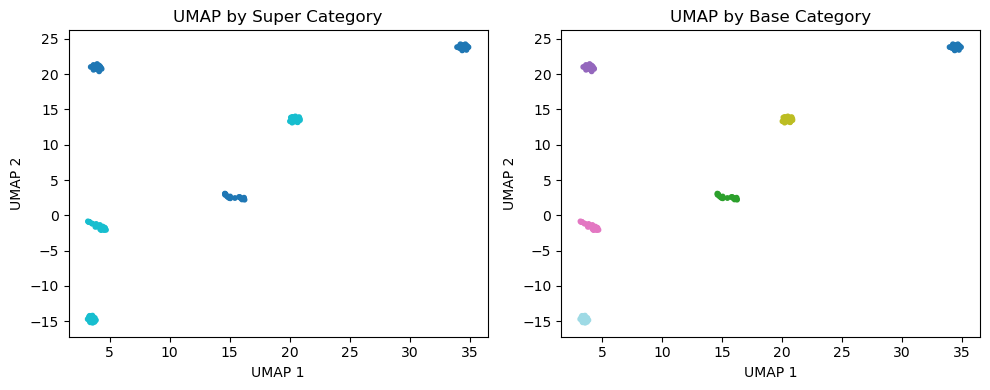

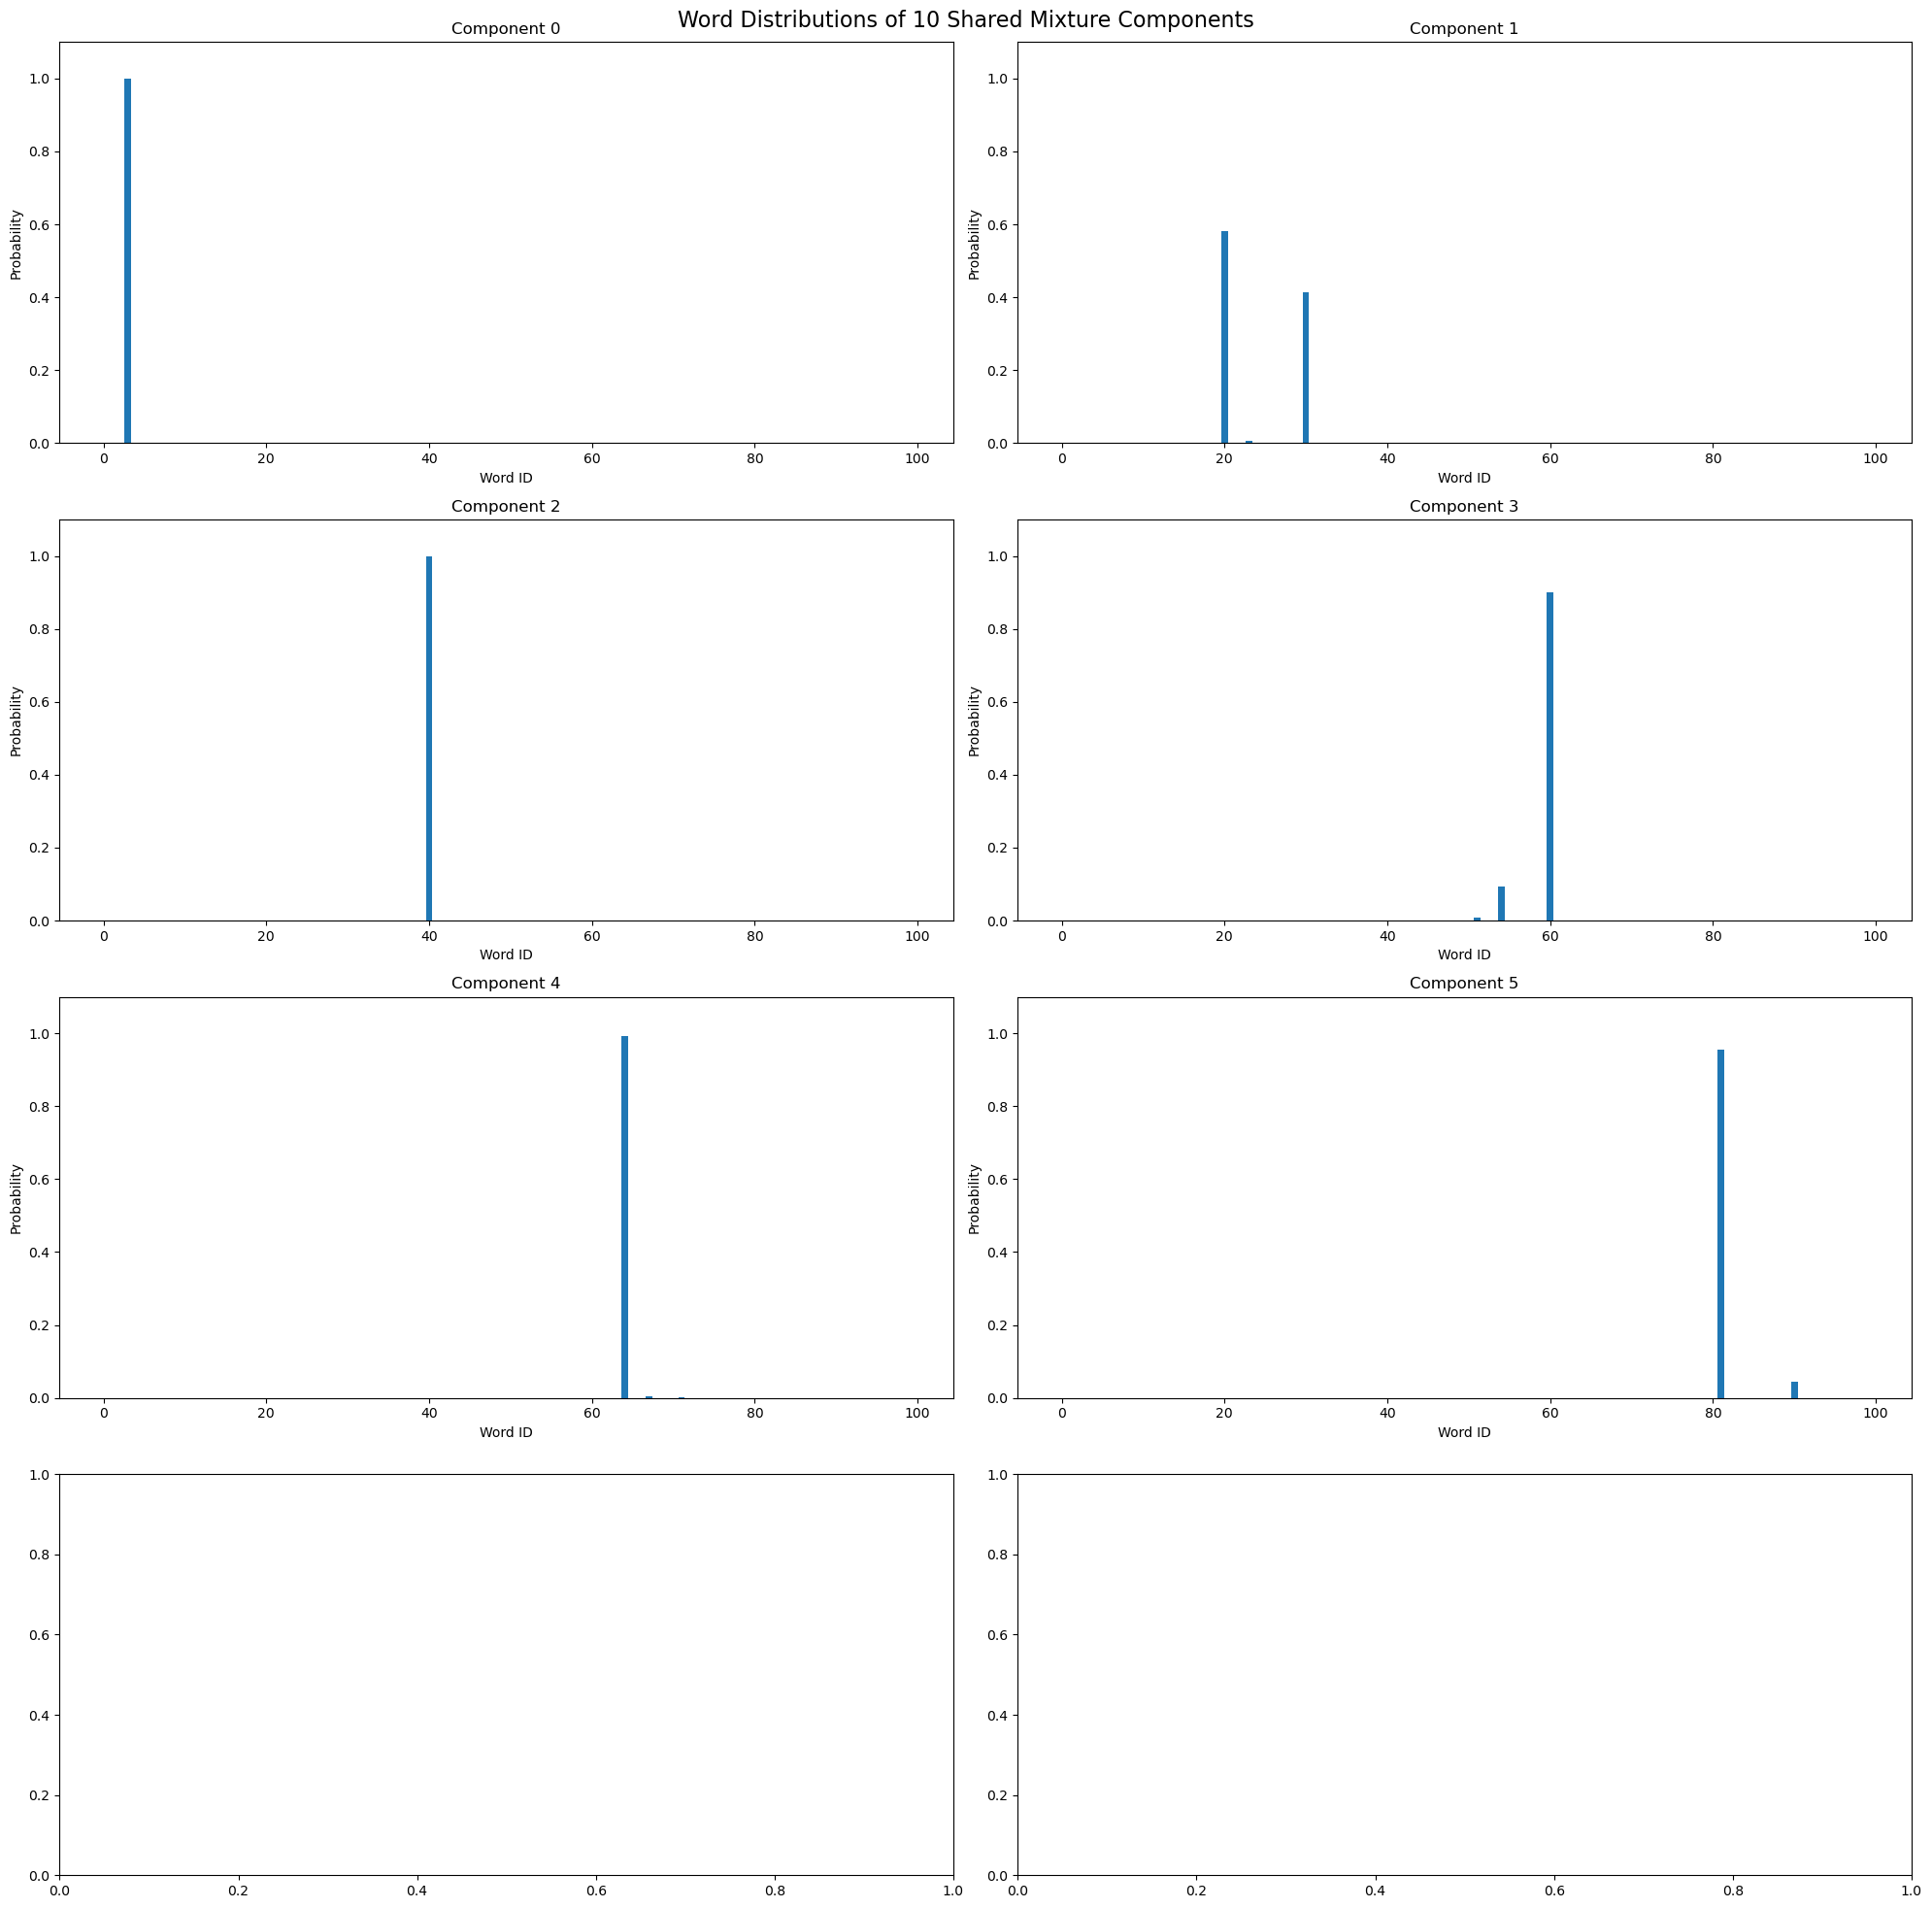

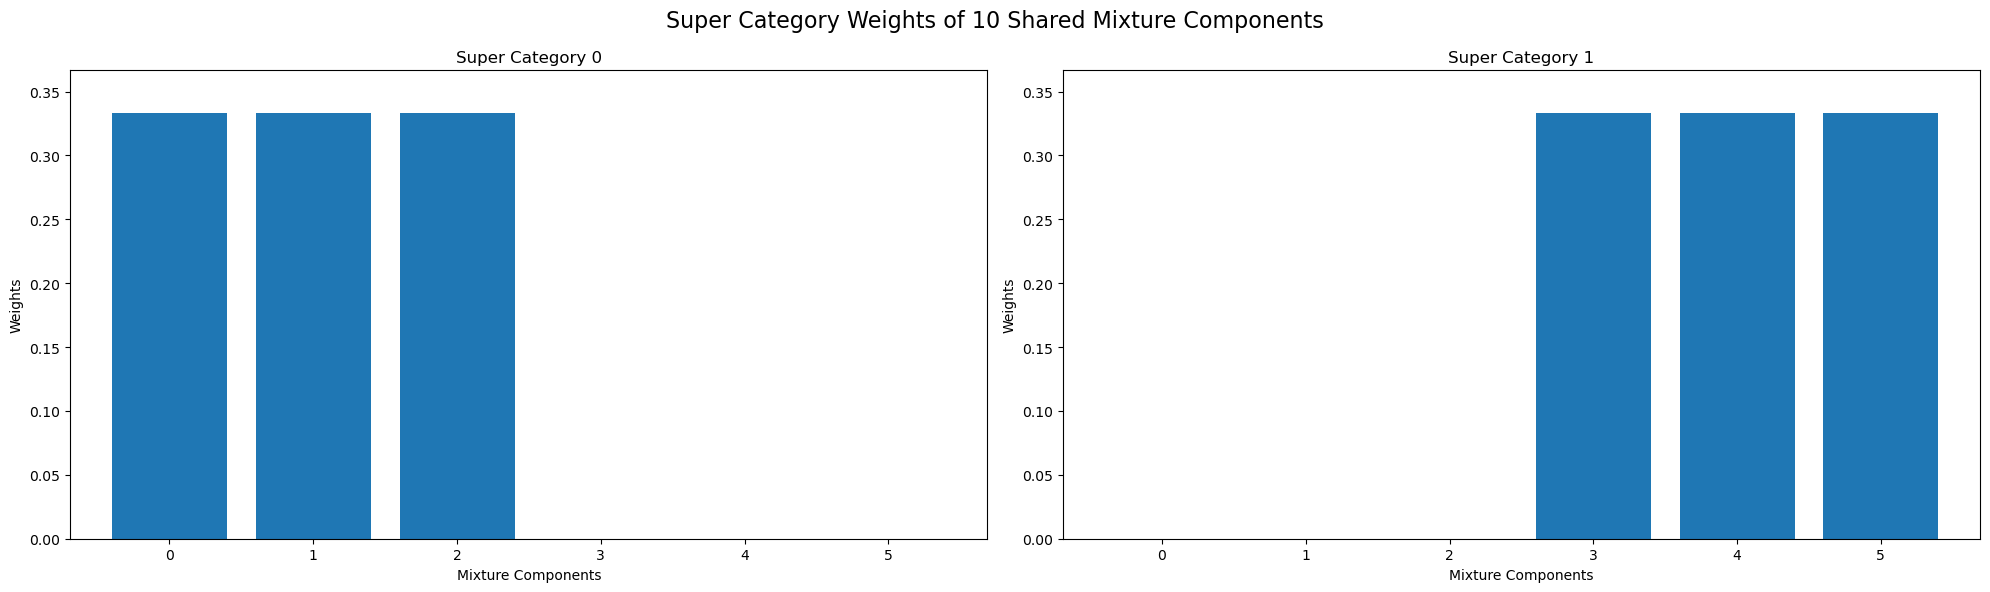

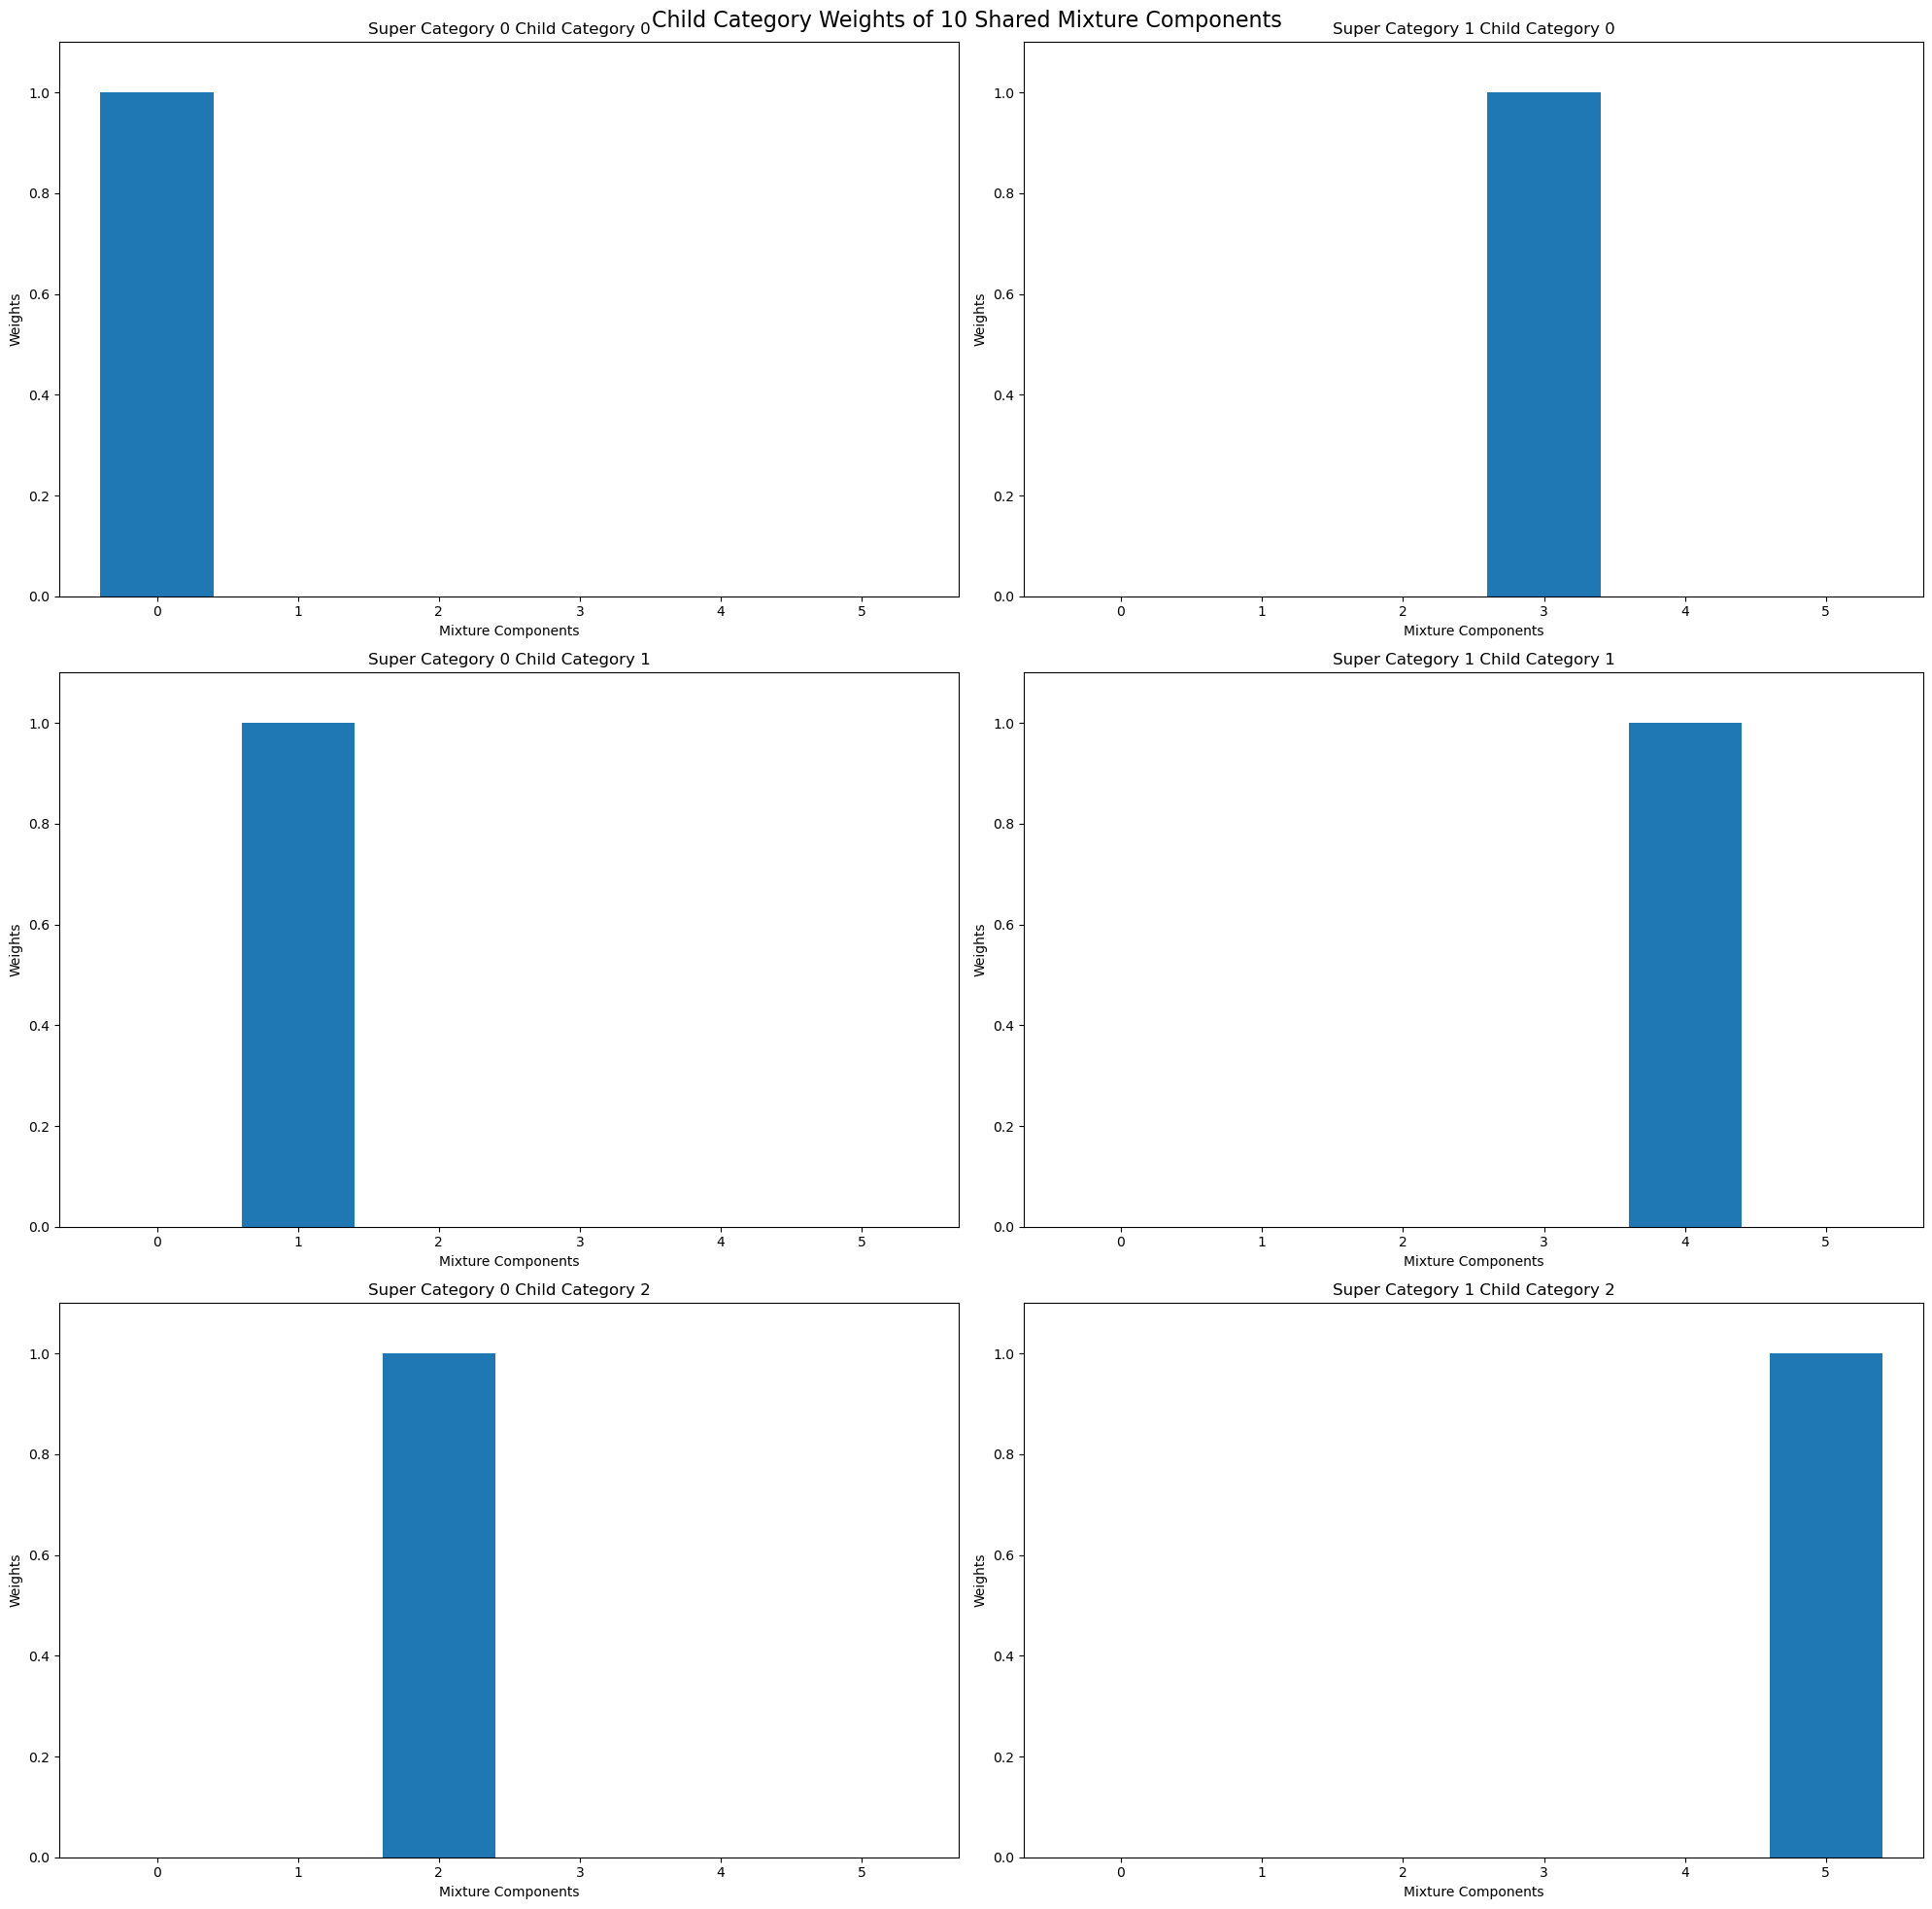

In [12]:
# === UMAP projection ===
reducer = umap.UMAP(random_state=0)
x_umap = reducer.fit_transform(x_agg.numpy().astype(np.float32))


# === UMAP Plots ===
plt.figure(figsize=(10, 4))

# Super category coloring
plt.subplot(1, 2, 1)
plt.scatter(x_umap[:, 0], x_umap[:, 1], c=data["super_labels"], cmap="tab10", s=10)
plt.title("UMAP by Super Category")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

# Base category coloring
plt.subplot(1, 2, 2)
plt.scatter(x_umap[:, 0], x_umap[:, 1], c=data["base_labels"], cmap="tab20", s=10)
plt.title("UMAP by Base Category")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

plt.tight_layout()
plt.show()

# === Mixture Component Word Distributions ===
num_components = struct_upbd["G0"]
V = data["x"].shape[-1]
word_dists = data["word_dists"]
super_mix_weights = data["super_mix_weights"]
child_mix_weights = data["child_mix_weights"]

# Bar plots for each component
fig, axs = plt.subplots(int(num_components/2)+1, 2, figsize=(20, 20))
for i in range(num_components):
    ax = axs[i // 2, i % 2]
    ax.bar(range(V), word_dists[i].numpy())
    ax.set_title(f"Component {i}")
    ax.set_xlabel("Word ID")
    ax.set_ylabel("Probability")
    ax.set_ylim(0, word_dists.max().item() * 1.1)

fig.suptitle("Word Distributions of 10 Shared Mixture Components", fontsize=16)
plt.tight_layout()
plt.show()

# Bar plots for each component
fig, axs = plt.subplots(1, 2, figsize=(20, 6))
for i in range(2):
    ax = axs[i]
    ax.bar(range(num_components), super_mix_weights[i].numpy())
    ax.set_title(f"Super Category {i}")
    ax.set_xlabel("Mixture Components")
    ax.set_ylabel("Weights")
    ax.set_ylim(0, super_mix_weights.max().item() * 1.1)

fig.suptitle("Super Category Weights of 10 Shared Mixture Components", fontsize=16)
plt.tight_layout()
plt.show()

# Bar plots for each component
fig, axs = plt.subplots(struct_upbd["G2"], struct_upbd["G1"], figsize=(20, 20))
for i in range(struct_upbd["G2"]):
    for j in range(struct_upbd["G1"]):
        ax = axs[i, j]
        ax.bar(range(num_components), child_mix_weights[i][j].numpy())
        ax.set_title(f"Super Category {j} Child Category {i}")
        ax.set_xlabel("Mixture Components")
        ax.set_ylabel("Weights")
        ax.set_ylim(0, child_mix_weights.max().item() * 1.1)

fig.suptitle("Child Category Weights of 10 Shared Mixture Components", fontsize=16)
plt.tight_layout()
plt.show()



🔁 Round 1 / 10
📌 Optimizing guide...


/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/pyro/util.py:303: UserWarning: Found vars in model but not guide: {'z3'}
  warnings.warn(f"Found vars in model but not guide: {bad_sites}")


  [Guide] Step 0, loss = 26894.14


/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/pyro/util.py:303: UserWarning: Found vars in model but not guide: {'z3'}
  warnings.warn(f"Found vars in model but not guide: {bad_sites}")


  [Guide] Step 100, loss = 25971.97
  [Guide] Step 200, loss = 24717.74
  [Guide] Step 300, loss = 24148.04
  [Guide] Step 400, loss = 23546.56
📌 Optimizing model...
  [Model] Step 0, loss = 23584.57
  [Model] Step 100, loss = 21984.45
  [Model] Step 200, loss = 22103.48
  [Model] Step 300, loss = 22368.04
  [Model] Step 400, loss = 21479.99

🔁 Round 2 / 10
📌 Optimizing guide...
  [Guide] Step 0, loss = 20413.33
  [Guide] Step 100, loss = 20418.80
  [Guide] Step 200, loss = 19833.93
  [Guide] Step 300, loss = 17789.86
  [Guide] Step 400, loss = 17450.35
📌 Optimizing model...
  [Model] Step 0, loss = 17084.49
  [Model] Step 100, loss = 17594.16
  [Model] Step 200, loss = 17697.12
  [Model] Step 300, loss = 16019.67
  [Model] Step 400, loss = 15804.70

🔁 Round 3 / 10
📌 Optimizing guide...
  [Guide] Step 0, loss = 15827.74
  [Guide] Step 100, loss = 16693.18
  [Guide] Step 200, loss = 15785.93
  [Guide] Step 300, loss = 15254.21
  [Guide] Step 400, loss = 14377.19
📌 Optimizing model...
  

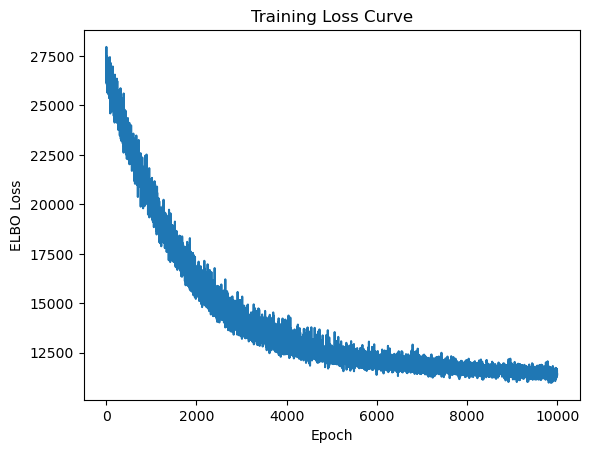

In [13]:
dataset = (data["x"], data["y"])
device = torch.device("cpu")
# Training settings
num_epochs = 1000
log_every = 100
lr = 1e-3

# Set up optimizer and ELBO
optim = pyro.optim.Adam({"lr": lr})

elbo = TraceEnum_ELBO(max_plate_nesting=1)
svi = SVI(model, guide, optim, loss=elbo)

# === Alternating training loop ===
num_rounds = 10
posterior_steps = 500
model_steps = 500
losses = []

for seed in range(0, 400, 100):
    pyro.clear_param_store()
    pyro.set_rng_seed(seed)

    # for epoch in range(num_epochs):
    #     pyro.clear_param_store()
    #     loss = svi.step(dataset, struct_upbd, vocab_size, device)
        
    #     losses.append(loss)
        
    #     if epoch % log_every == 0:
    #         print(f"Epoch {epoch:04d}  Loss: {loss:.4f}")
    #         optim.set_state({"lr": lr/(epoch+1)})
    for round_idx in range(num_rounds):
        print(f"\n🔁 Round {round_idx + 1} / {num_rounds}")
    
        # Phase 1: Guide (Posterior inference)
        set_requires_grad_by_prefix("model_", False)
        set_requires_grad_by_prefix("guide_", True)
        print("📌 Optimizing guide...")
        for step in range(posterior_steps):
            loss = svi.step(dataset, struct_upbd, vocab_size, device)
            losses.append(loss)
            if step % 100 == 0:
                print(f"  [Guide] Step {step}, loss = {loss:.2f}")
    
        # Phase 2: Model (Generative parameter update)
        set_requires_grad_by_prefix("guide_", False)
        set_requires_grad_by_prefix("model_", True)
        print("📌 Optimizing model...")
        for step in range(model_steps):
            loss = svi.step(dataset, struct_upbd, vocab_size, device)
            losses.append(loss)
            if step % 100 == 0:
                print(f"  [Model] Step {step}, loss = {loss:.2f}")
    # Optional: plot loss
    try:
        import matplotlib.pyplot as plt
        plt.plot(losses)
        plt.xlabel("Epoch")
        plt.ylabel("ELBO Loss")
        plt.title("Training Loss Curve")
        plt.show()
    except ImportError:
        pass
    break



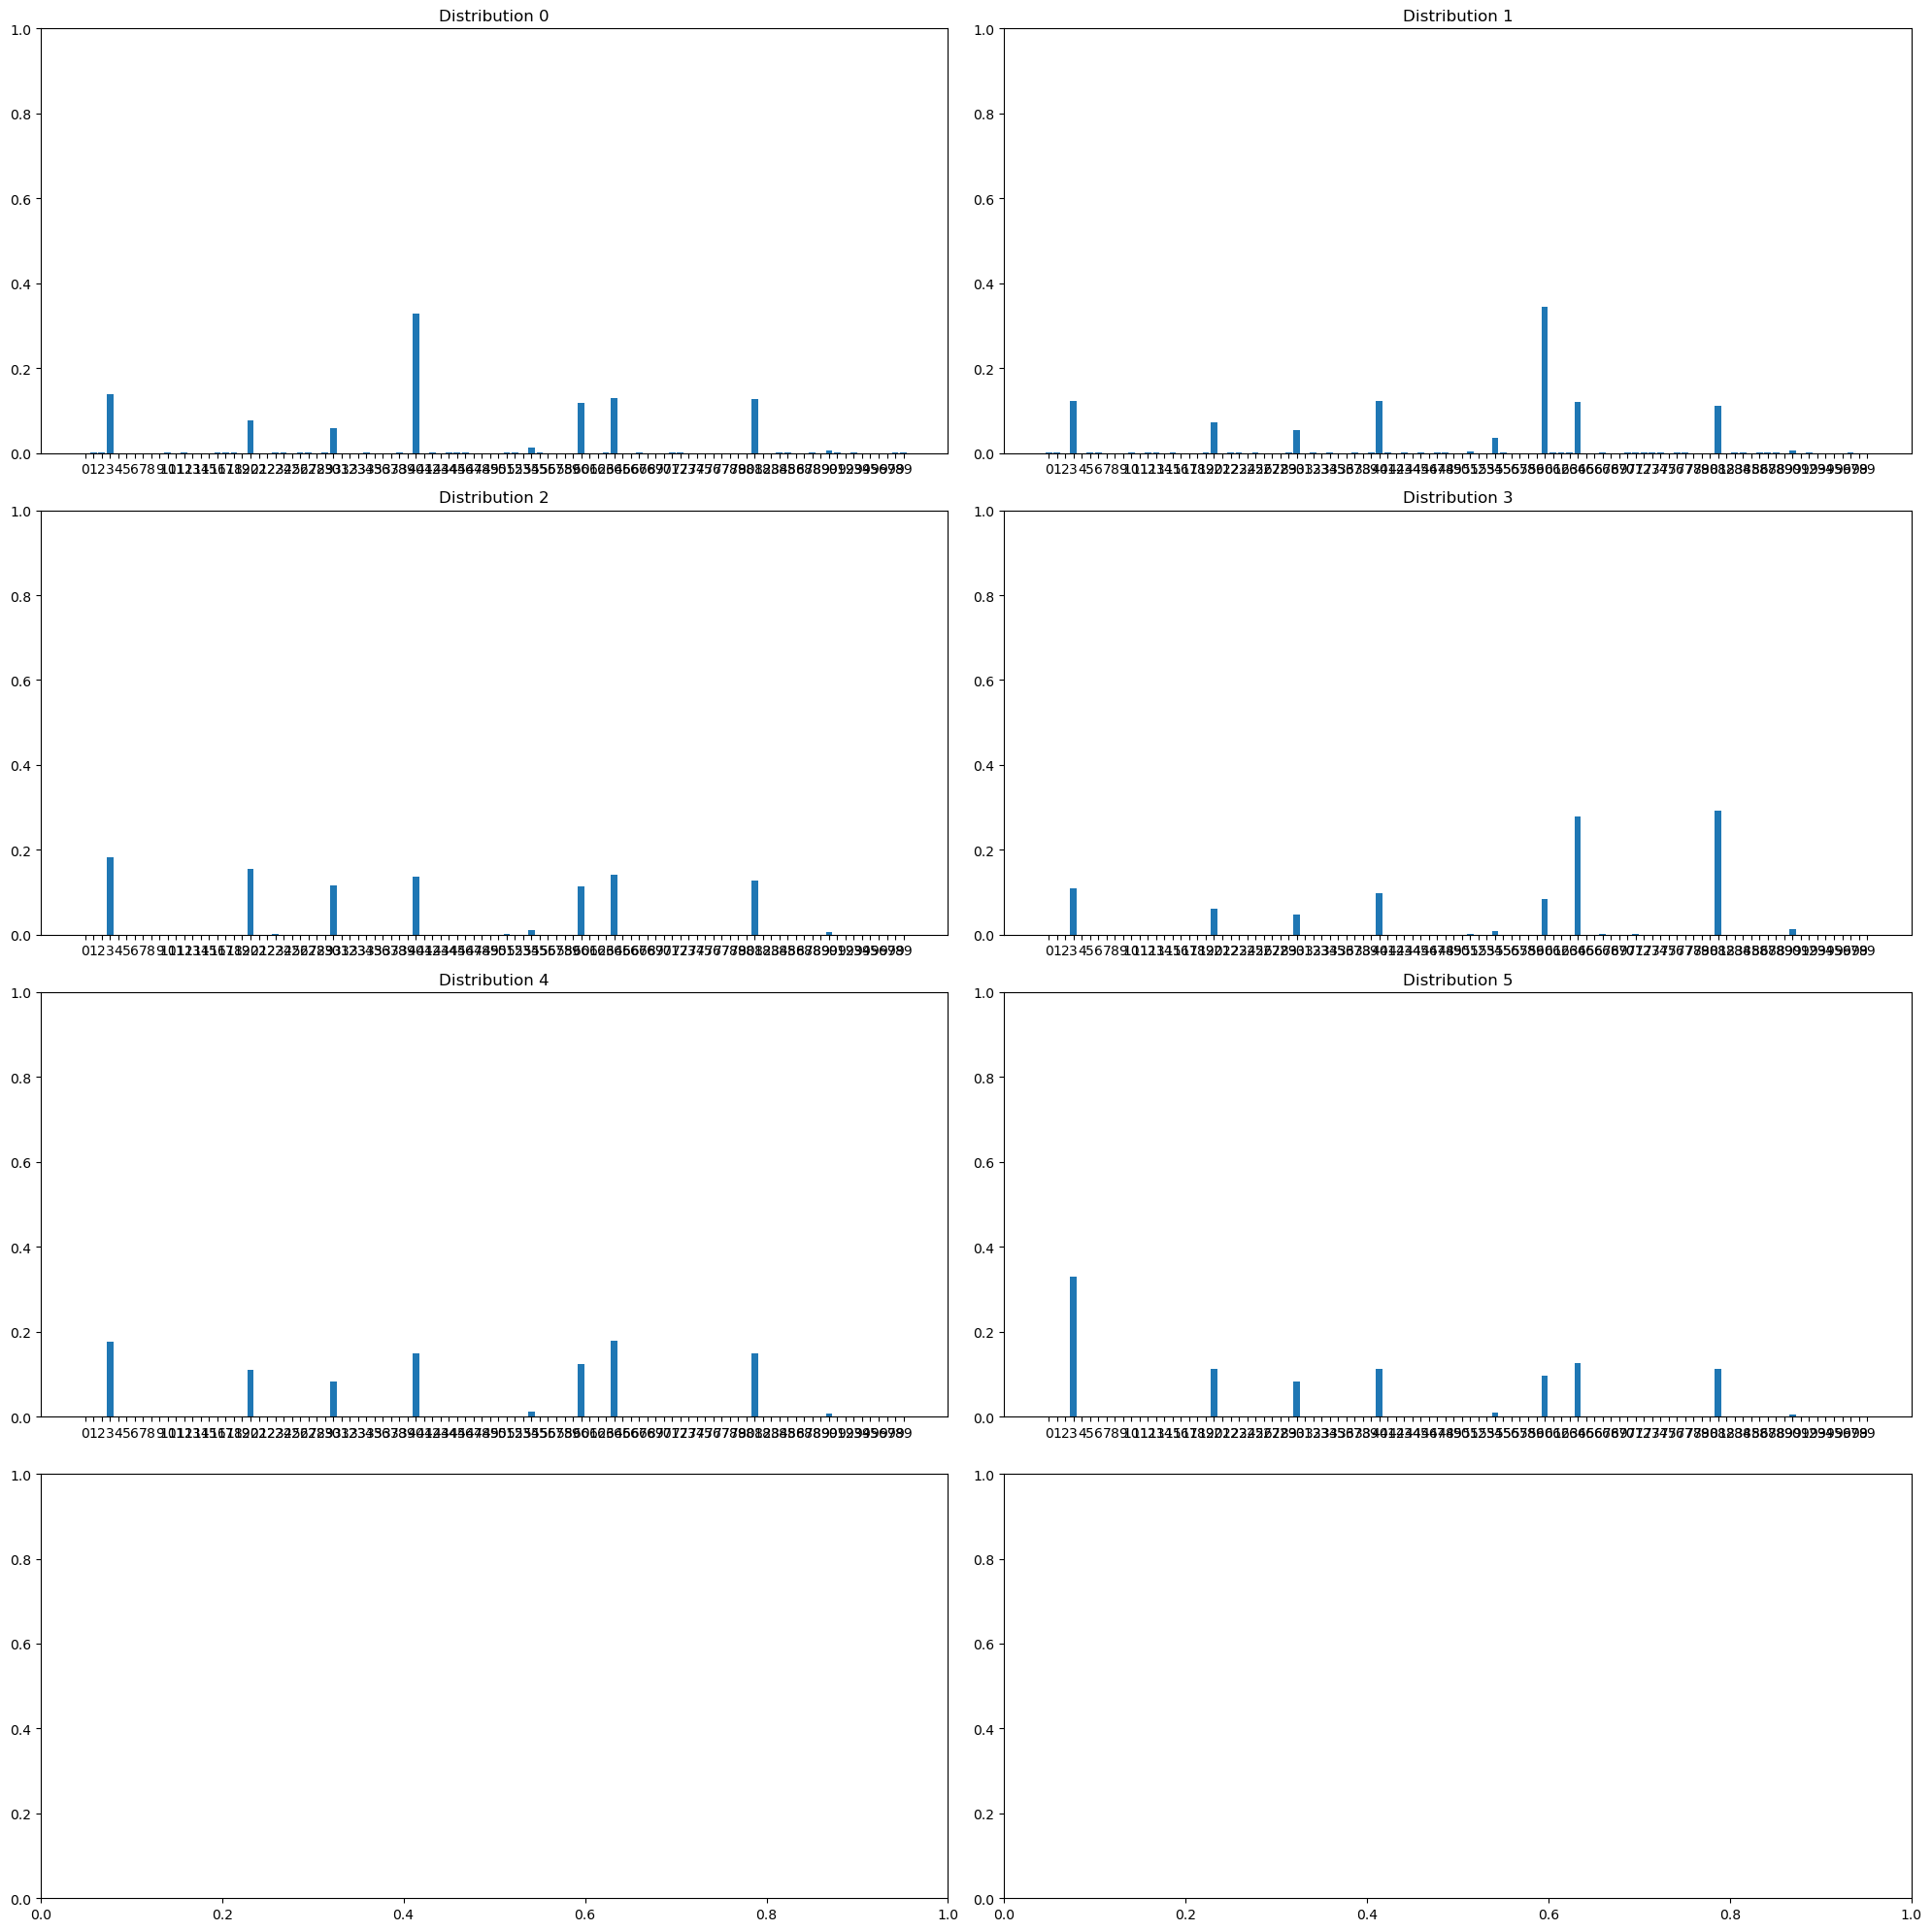

In [14]:
import torch
import matplotlib.pyplot as plt

# Example tensor: 10 distributions over 5 categories
params = pyro.get_param_store().get_param("model_phi_u").detach()

fig, axs = plt.subplots(int(struct_upbd["G0"]/2)+1, 2, figsize=(20, 20))

for i in range(struct_upbd["G0"]):
    ax = axs[i // 2, i % 2]
    ax.bar(range(params.size(1)), params[i].cpu().numpy())
    ax.set_title(f'Distribution {i}')
    ax.set_xticks(range(params.size(1)))
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()


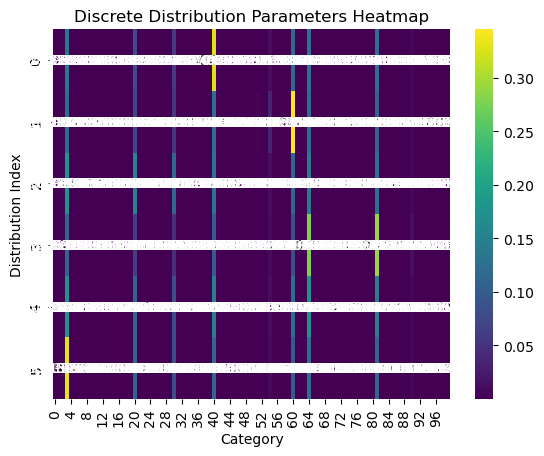

In [15]:
import seaborn as sns

sns.heatmap(params.numpy(), cmap='viridis', annot=True, cbar=True)
plt.xlabel("Category")
plt.ylabel("Distribution Index")
plt.title("Discrete Distribution Parameters Heatmap")
plt.show()


In [16]:
import torch
import torch.nn.functional as F

# Simulated inputs

true_params = data["word_dists"]
candidate_params = pyro.get_param_store().get_param("model_phi_u").detach()
# print(true_params.shape)
# print(candidate_params.shape)

# Normalize to make them valid distributions
true_params /= true_params.sum(dim=1, keepdim=True)
candidate_params /= candidate_params.sum(dim=1, keepdim=True)
assert torch.allclose(true_params.sum(dim=1), torch.ones_like(true_params.sum(dim=1)), atol=1e-4)
assert torch.allclose(candidate_params.sum(dim=1), torch.ones_like(candidate_params.sum(dim=1)), atol=1e-4)


# Compute Jensen-Shannon distance between all pairs
# def jensen_shannon(p, q, eps=1e-8):
#     # Normalize inputs to ensure valid distributions
#     p = p / (p.sum(dim=-1, keepdim=True) + eps)
#     q = q / (q.sum(dim=-1, keepdim=True) + eps)
#     m = 0.5 * (p + q)

#     # Compute KL divergences: kl_div expects log-prob as input
#     kl_pm = F.kl_div((p + eps).log(), m, reduction='none').sum(-1)
#     kl_qm = F.kl_div((q + eps).log(), m, reduction='none').sum(-1)

#     return 0.5 * (kl_pm + kl_qm)
def jensen_shannon(p, q, eps=1e-8):
    p = p / (p.sum(dim=-1, keepdim=True) + eps)
    q = q / (q.sum(dim=-1, keepdim=True) + eps)
    m = 0.5 * (p + q)

    kl_pm = (p * ((p + eps).log() - (m + eps).log())).sum(-1)
    kl_qm = (q * ((q + eps).log() - (m + eps).log())).sum(-1)

    return 0.5 * (kl_pm + kl_qm)
# Expand for broadcasting: (6, 1, K) and (1, 20, K) → (6, 20, K)
p_exp = true_params[:, None, :]  # shape [6, 1, K]
q_exp = candidate_params[None, :, :]  # shape [1, 20, K]

# JS similarity matrix: shape [6, 20]
js_matrix = jensen_shannon(p_exp, q_exp)

# Optional: convert to similarity score (1 - distance)
similarity = 1 - js_matrix

# print(similarity)


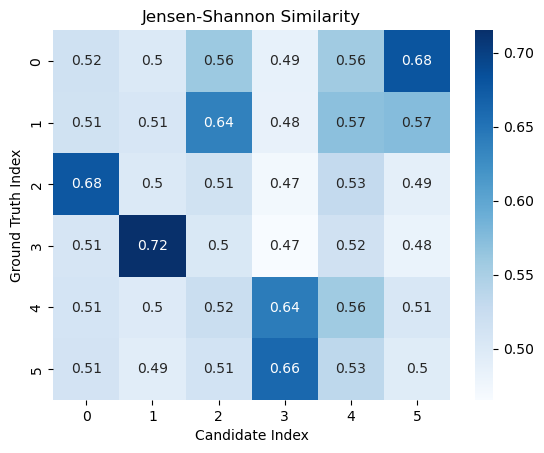

In [17]:
# import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(similarity.numpy(), annot=True, cmap='Blues')
plt.xlabel("Candidate Index")
plt.ylabel("Ground Truth Index")
plt.title("Jensen-Shannon Similarity")
plt.show()


tensor([-3.0000, -1.8000, -0.6000,  0.6000,  1.8000,  3.0000])
tensor([-2.9672, -1.7786, -0.5897,  0.2437,  0.6115,  2.4268])
tensor([0.0877, 0.1928, 0.2709, 0.6816, 1.9655, 0.1628])


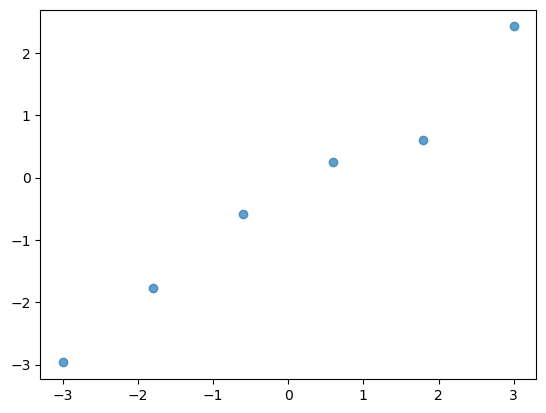

In [35]:
true_params = torch.linspace(-3, 3, steps=num_components)
candidate_params = candidate_params = pyro.get_param_store().get_param("model_phi_y_mu").detach()
# Expand for broadcasting: (6, 1, K) and (1, 20, K) → (6, 20, K)
p_exp = true_params
q_exp,  _ = torch.sort(candidate_params)
print(p_exp)
print(q_exp)
print(pyro.get_param_store().get_param("model_phi_y_sigma").detach())
plt.scatter(p_exp, q_exp, alpha=0.7)



In [19]:
from pyro.infer import Predictive

# guide: your trained guide
# model: your model without obs
# num_samples: number of predictive samples

predictive = Predictive(model, guide=guide, num_samples=1000)

# Omit `data` or provide partial input depending on your model
samples = predictive((dataset[0].to(device), None),struct_upbd, vocab_size, device)  # or data=..., depending on your model's inputs

In [38]:
# from pyro.infer import Predictive, infer_discrete

# # Assume `guide` is your trained guide and `model` is the model with discrete `z`
# # `temperature=0` means use MAP instead of sampling

# # Wrap the model to get discrete values (MAP)
# map_model = infer_discrete(model, temperature=0, first_available_dim=-1)

# # Run prediction with MAP value for discrete latent
# predictive = Predictive(map_model, guide=guide, num_samples=100)
# samples = predictive((dataset[0].to(device), None),struct_upbd, vocab_size, device)


In [20]:
predict = samples['y'][-100:].mean(dim=0)
predict_var = samples['y'][-100:].var(dim=0)

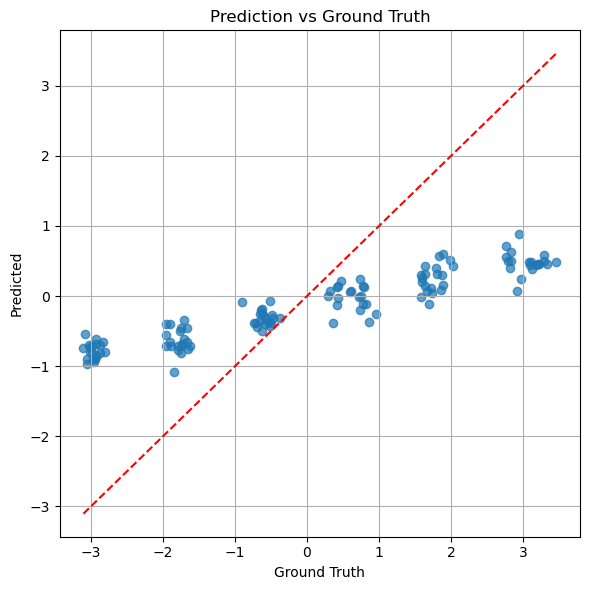

In [21]:
y_true = dataset[1]     # ground truth
y_pred = predict # predicted (with noise)
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.7)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')  # y = x line
plt.xlabel("Ground Truth")
plt.ylabel("Predicted")
plt.title("Prediction vs Ground Truth")
plt.grid(True)
plt.tight_layout()
plt.show()

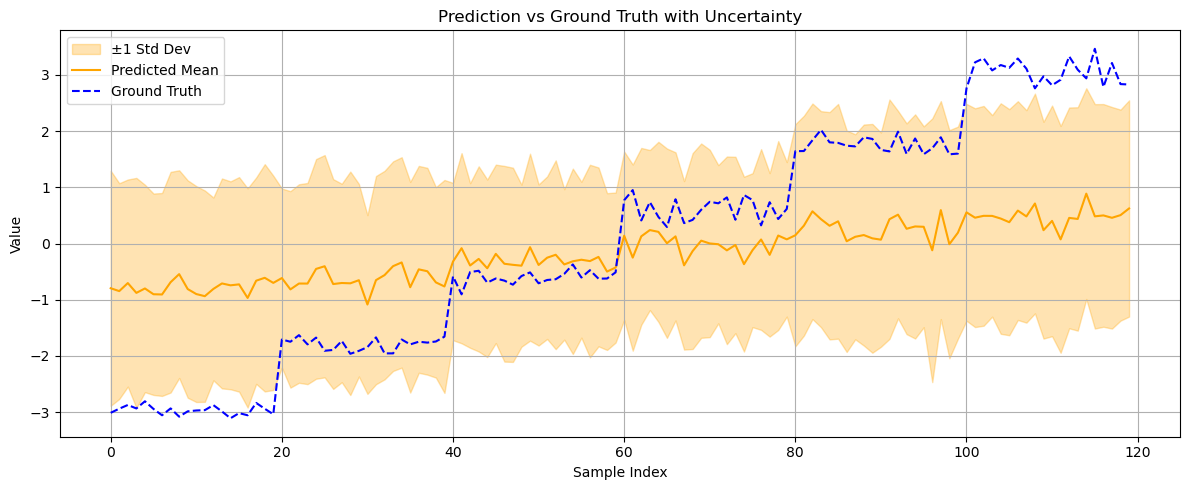

In [22]:

# Example data
N=120
mean_pred = y_pred
var_pred = predict_var

std_pred = var_pred.sqrt()
x = torch.arange(N)

plt.figure(figsize=(12, 5))

# Confidence interval (±1 std)
plt.fill_between(x, mean_pred - std_pred, mean_pred + std_pred, color="orange", alpha=0.3, label="±1 Std Dev")

# Prediction mean
plt.plot(x, mean_pred, color="orange", label="Predicted Mean")

# Ground truth
plt.plot(x, y_true, color="blue", linestyle="--", label="Ground Truth")

plt.xlabel("Sample Index")
plt.ylabel("Value")
plt.title("Prediction vs Ground Truth with Uncertainty")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [23]:
predict_beta = samples['G2']
weights = mix_weights(predict_beta)[..., :-1]
mean_w = weights.mean(dim=0)
var_w = weights.var(dim=0)
print(mean_w.shape)

torch.Size([3, 2, 6])


tensor([[0.6673, 0.6060, 0.6690, 0.6158, 0.6647, 0.6074],
        [0.5318, 0.5379, 0.5340, 0.5404, 0.5356, 0.5396],
        [0.5948, 0.5873, 0.5853, 0.5840, 0.6017, 0.5843],
        [0.4956, 0.4883, 0.4906, 0.4833, 0.4907, 0.4891],
        [0.5741, 0.5494, 0.5837, 0.5447, 0.5705, 0.5466],
        [0.3069, 0.4919, 0.3069, 0.4900, 0.3069, 0.4944]])


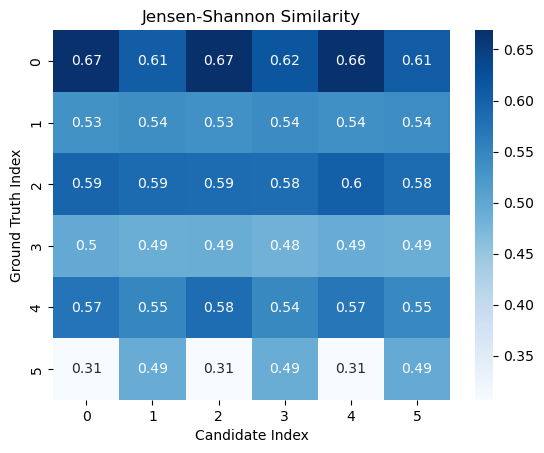

In [24]:
true_params = data["child_mix_weights"].reshape(-1, struct_upbd["G0"])
candidate_params = mean_w.reshape(-1, struct_upbd["G0"])

p_exp = true_params[:, None, :]  # shape [6, 1, K]
q_exp = candidate_params[None, :, :]  # shape [1, 20, K]

# JS similarity matrix: shape [6, 20]
js_matrix = jensen_shannon(p_exp, q_exp)

# Optional: convert to similarity score (1 - distance)
similarity = 1 - js_matrix

print(similarity)

sns.heatmap(similarity.numpy(), annot=True, cmap='Blues')
plt.xlabel("Candidate Index")
plt.ylabel("Ground Truth Index")
plt.title("Jensen-Shannon Similarity")
plt.show()

tensor([[1.0000, 0.3069, 0.3069, 0.3069, 0.3069, 0.3069],
        [0.3069, 1.0000, 0.3069, 0.3069, 0.3069, 0.3069],
        [0.3069, 0.3069, 1.0000, 0.3069, 0.3069, 0.3069],
        [0.3069, 0.3069, 0.3069, 1.0000, 0.3069, 0.3069],
        [0.3069, 0.3069, 0.3069, 0.3069, 1.0000, 0.3069],
        [0.3069, 0.3069, 0.3069, 0.3069, 0.3069, 1.0000]])


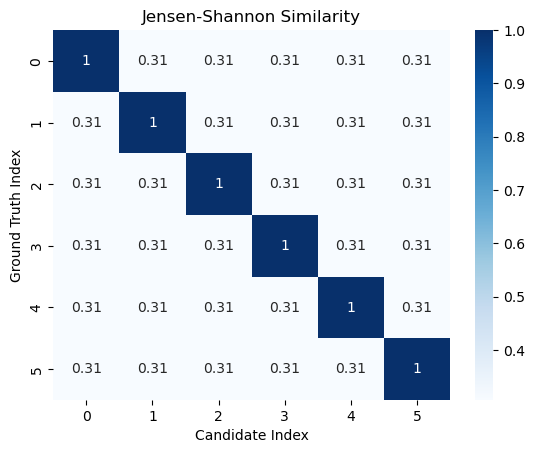

In [25]:
true_params = data["child_mix_weights"].reshape(-1, struct_upbd["G0"])
candidate_params = true_params

p_exp = true_params[:, None, :]  # shape [6, 1, K]
q_exp = candidate_params[None, :, :]  # shape [1, 20, K]

# JS similarity matrix: shape [6, 20]
js_matrix = jensen_shannon(p_exp, q_exp)

# Optional: convert to similarity score (1 - distance)
similarity = 1 - js_matrix

print(similarity)

sns.heatmap(similarity.numpy(), annot=True, cmap='Blues')
plt.xlabel("Candidate Index")
plt.ylabel("Ground Truth Index")
plt.title("Jensen-Shannon Similarity")
plt.show()

torch.Size([2, 6])
tensor([[0.8932, 0.8918],
        [0.5941, 0.5971]])


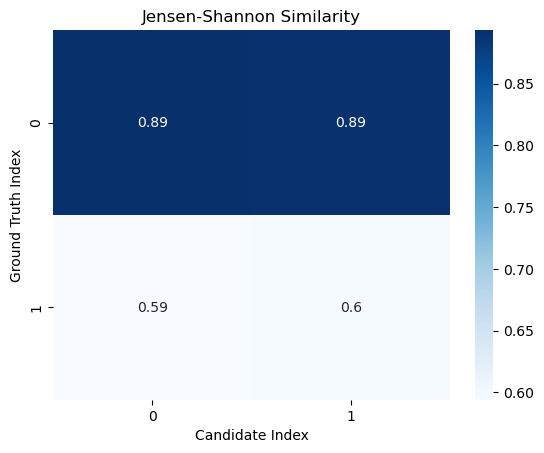

In [26]:
predict_beta = samples['G1']
weights = mix_weights(predict_beta)[..., :-1]
mean_w = weights.mean(dim=0)
var_w = weights.var(dim=0)
print(mean_w.shape)
true_params = data["super_mix_weights"].reshape(-1, struct_upbd["G0"])
candidate_params = mean_w.reshape(-1, struct_upbd["G0"])

p_exp = true_params[:, None, :]  # shape [6, 1, K]
q_exp = candidate_params[None, :, :]  # shape [1, 20, K]

# JS similarity matrix: shape [6, 20]
js_matrix = jensen_shannon(p_exp, q_exp)

# Optional: convert to similarity score (1 - distance)
similarity = 1 - js_matrix

print(similarity)

sns.heatmap(similarity.numpy(), annot=True, cmap='Blues')
plt.xlabel("Candidate Index")
plt.ylabel("Ground Truth Index")
plt.title("Jensen-Shannon Similarity")
plt.show()

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap
import torch
import torch.nn.functional as F

# Set seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Parameters
num_super = 3
num_base_per_super = 4
num_mixtures = 10
num_features = 36
samples_per_base = 50

# 1. Mixture component prototypes (Bernoulli distributions)
mixture_prototypes = torch.rand(num_mixtures, num_features)

# 2. Super category weights (Dirichlet over mixtures)
super_weights = torch.distributions.Dirichlet(torch.ones(num_mixtures)).sample((num_super,))

# 3. Base category weights (perturbed super weights)
base_weights = []
for s in range(num_super):
    for _ in range(num_base_per_super):
        noise = 0.05 * torch.randn(num_mixtures)
        perturbed = F.softmax(super_weights[s] + noise, dim=0)
        base_weights.append(perturbed)
base_weights = torch.stack(base_weights)  # shape: (num_super*num_base, num_mixtures)

# 4. Sample binary data and regression targets
X = []
y = []
labels_super = []
labels_base = []

for base_id, weights in enumerate(base_weights):
    for _ in range(samples_per_base):
        # Sample mixture component index
        component_id = torch.multinomial(weights, 1).item()
        prob = mixture_prototypes[component_id]
        
        # Sample binary feature
        binary_sample = torch.bernoulli(prob)
        
        # Define regression target (e.g., linear over component_id)
        reg_target = torch.sin(torch.tensor(component_id * np.pi / num_mixtures)) + 0.1 * torch.randn(1)

        X.append(binary_sample.numpy())
        y.append(reg_target.item())
        labels_base.append(base_id)
        labels_super.append(base_id // num_base_per_super)

X = np.array(X)
y = np.array(y)
labels_super = np.array(labels_super)
labels_base = np.array(labels_base)


/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


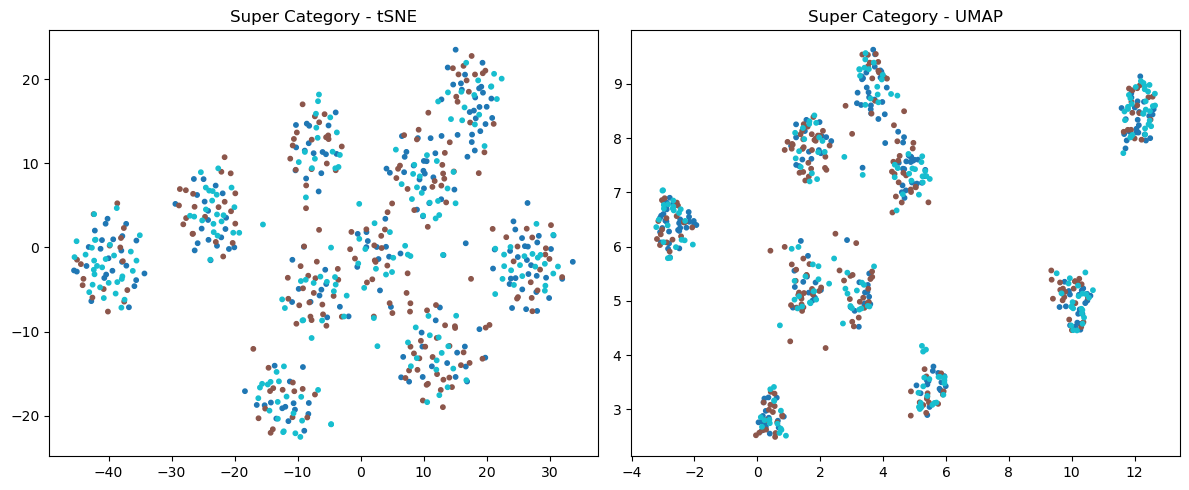

/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


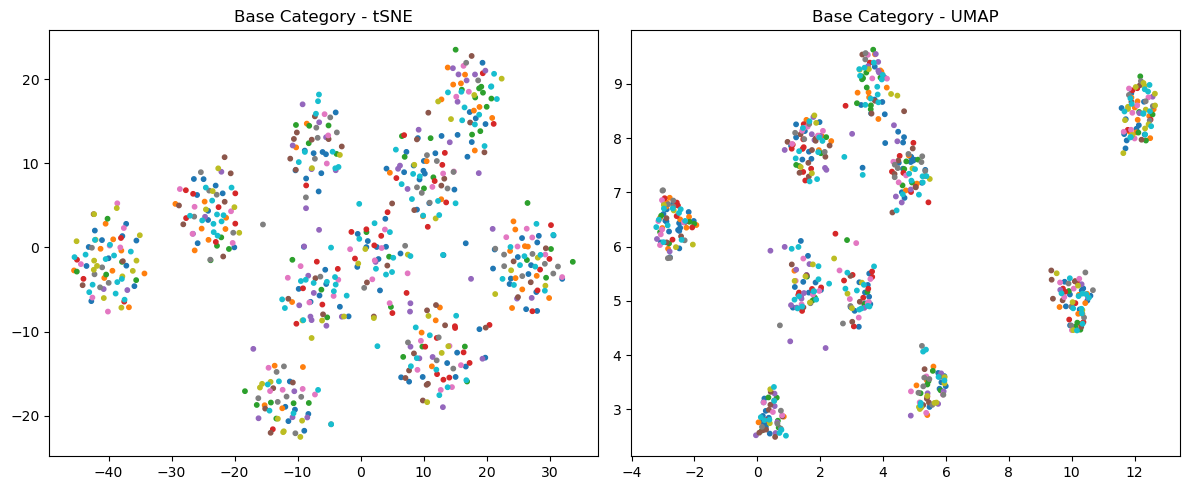

In [2]:
def visualize(X, labels, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    X_tsne = TSNE(n_components=2, perplexity=30, random_state=0).fit_transform(X)
    axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='tab10', s=10)
    axes[0].set_title(f"{title} - tSNE")

    X_umap = umap.UMAP(random_state=0).fit_transform(X)
    axes[1].scatter(X_umap[:, 0], X_umap[:, 1], c=labels, cmap='tab10', s=10)
    axes[1].set_title(f"{title} - UMAP")
    plt.tight_layout()
    plt.show()

# Visualize by super category
visualize(X, labels_super, "Super Category")

# Visualize by base category
visualize(X, labels_base, "Base Category")


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap
import torch
import torch.nn.functional as F

np.random.seed(42)
torch.manual_seed(42)

# Parameters
num_super = 3
num_base_per_super = 4
num_mixtures = 10
num_features = 36
samples_per_base = 50

# 1. Mixture component prototypes: binary templates (clearer structure)
mixture_prototypes = torch.randint(0, 2, (num_mixtures, num_features)).float()

# 2. Super category: sharp mixture weights (1-hot or low-temp softmax)
super_weights = []
for i in range(num_super):
    idx = torch.randint(0, num_mixtures, (1,))
    vec = torch.zeros(num_mixtures)
    vec[idx] = 1.0
    super_weights.append(vec)
super_weights = torch.stack(super_weights)

# 3. Base categories: small noise around the super weights
base_weights = []
for s in range(num_super):
    for _ in range(num_base_per_super):
        noise = 0.1 * torch.randn(num_mixtures)
        perturbed = F.softmax(super_weights[s] + noise, dim=0)
        base_weights.append(perturbed)
base_weights = torch.stack(base_weights)

# 4. Generate samples
X, y = [], []
labels_super, labels_base = [], []

for base_id, weights in enumerate(base_weights):
    for _ in range(samples_per_base):
        component_id = torch.multinomial(weights, 1).item()
        prototype = mixture_prototypes[component_id]

        binary_sample = torch.bernoulli(prototype)

        # Strong regression signal: component ID plus optional noise
        reg_target = component_id + 0.1 * torch.randn(1)

        X.append(binary_sample.numpy())
        y.append(reg_target.item())
        labels_base.append(base_id)
        labels_super.append(base_id // num_base_per_super)

X = np.array(X)
y = np.array(y)
labels_base = np.array(labels_base)
labels_super = np.array(labels_super)


/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


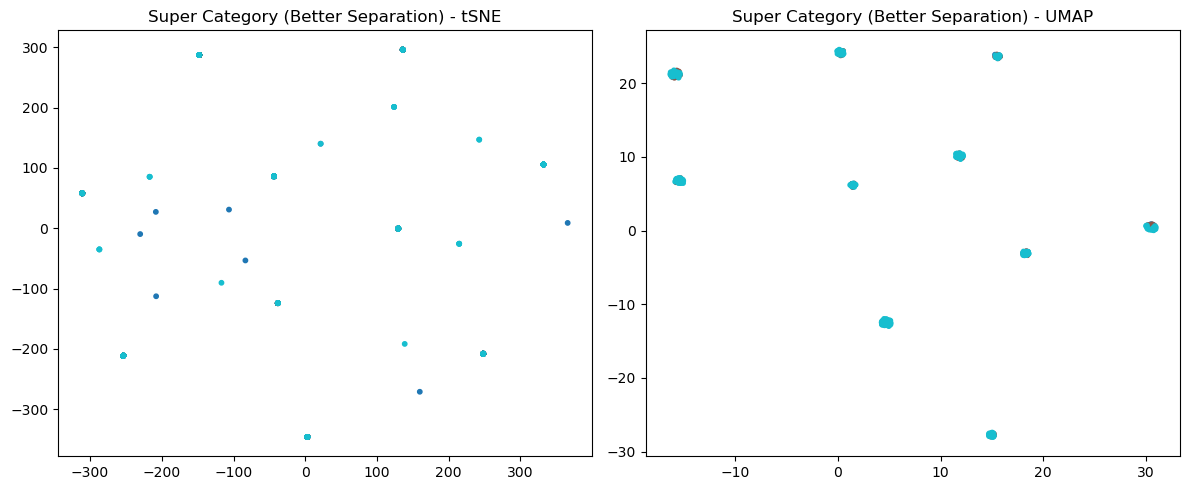

/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


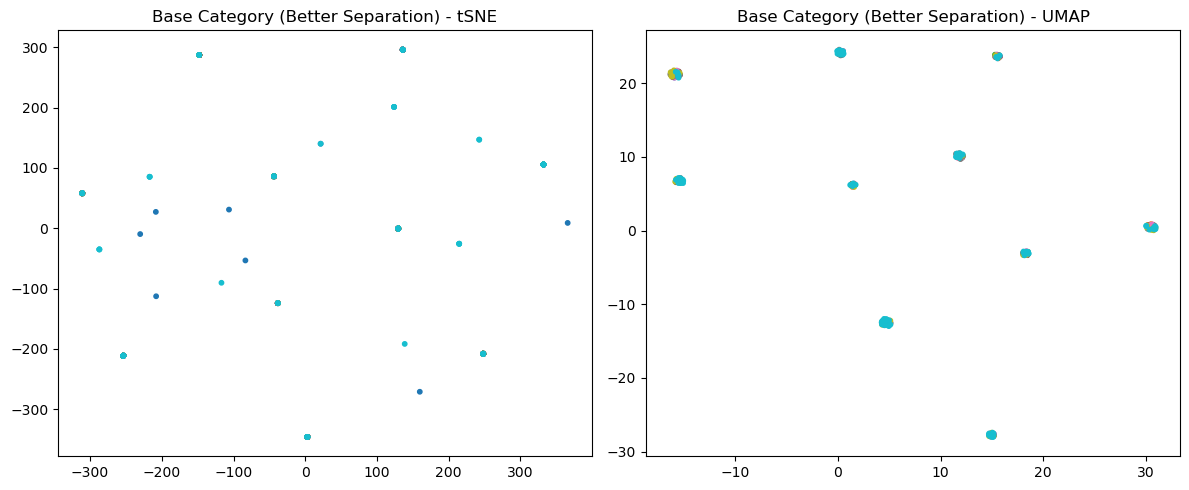

In [4]:
def visualize(X, labels, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    X_tsne = TSNE(n_components=2, perplexity=30, random_state=0).fit_transform(X)
    axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='tab10', s=10)
    axes[0].set_title(f"{title} - tSNE")

    X_umap = umap.UMAP(random_state=0).fit_transform(X)
    axes[1].scatter(X_umap[:, 0], X_umap[:, 1], c=labels, cmap='tab10', s=10)
    axes[1].set_title(f"{title} - UMAP")
    plt.tight_layout()
    plt.show()

visualize(X, labels_super, "Super Category (Better Separation)")
visualize(X, labels_base, "Base Category (Better Separation)")


In [7]:
import numpy as np
import torch

# Parameters
num_super = 3
num_base_per_super = 4
num_mixtures = num_super * num_base_per_super  # One unique mixture per base category
num_features = 36
samples_per_base = 50

torch.manual_seed(42)
np.random.seed(42)

# Step 1: Generate super-category prototypes (binary)
super_prototypes = torch.randint(0, 2, (num_super, num_features)).float()

# Step 2: For each base category, generate a unique but similar prototype
base_prototypes = []

for super_id in range(num_super):
    super_proto = super_prototypes[super_id]
    for _ in range(num_base_per_super):
        # Flip a small number of bits to get distinct but nearby base prototype
        proto = super_proto.clone()
        flip_mask = torch.rand(num_features) < 0.1  # 10% bits flipped
        proto[flip_mask] = 1 - proto[flip_mask]
        base_prototypes.append(proto)

base_prototypes = torch.stack(base_prototypes)  # shape: (num_bases, num_features)

# Step 3: Sample data using each base prototype
X = []
y = []
labels_base = []
labels_super = []

for base_id, proto in enumerate(base_prototypes):
    super_id = base_id // num_base_per_super
    for _ in range(samples_per_base):
        # Optional: flip a few bits to avoid all samples being identical
        noisy_sample = proto.clone()
        flip_mask = torch.rand(num_features) < 0.05  # 5% flip noise
        noisy_sample[flip_mask] = 1 - noisy_sample[flip_mask]
        
        X.append(noisy_sample.numpy())
        y.append(base_id)  # regression target = base category ID (or use something else)
        labels_base.append(base_id)
        labels_super.append(super_id)

# Convert to numpy arrays
X = np.array(X)
y = np.array(y)
labels_base = np.array(labels_base)
labels_super = np.array(labels_super)


/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


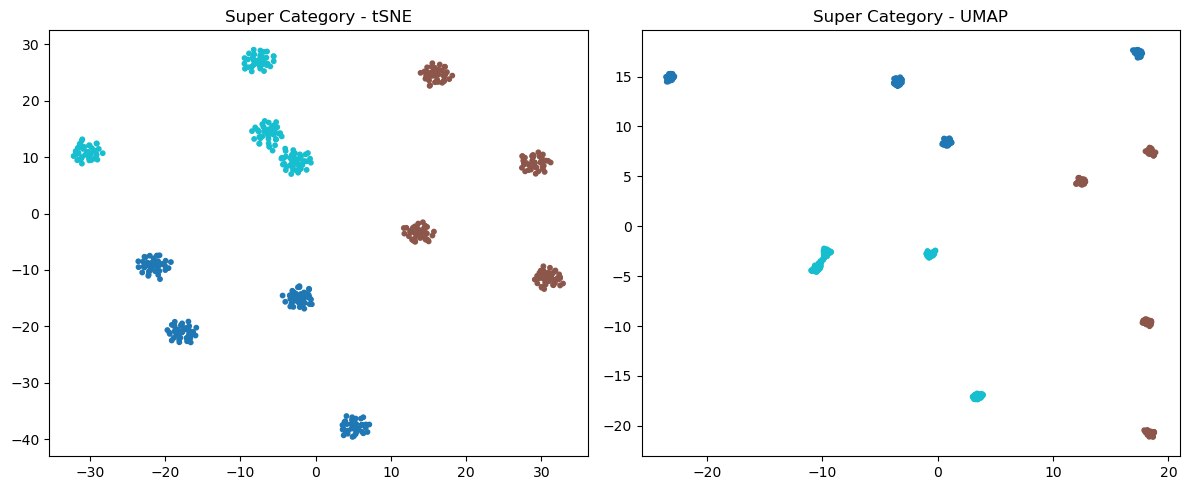

/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


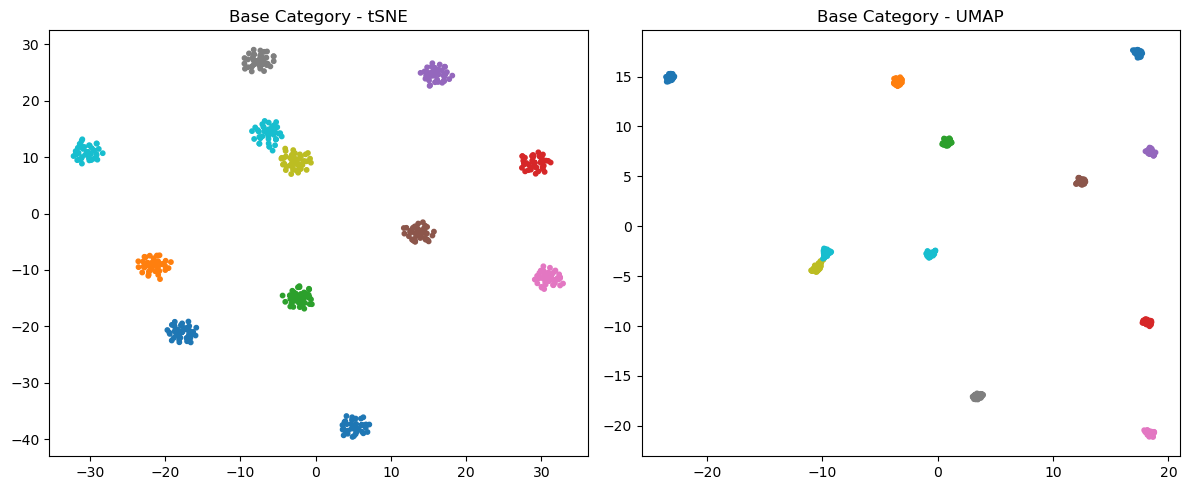

In [8]:
def visualize(X, labels, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    X_tsne = TSNE(n_components=2, perplexity=30, random_state=0).fit_transform(X)
    axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='tab10', s=10)
    axes[0].set_title(f"{title} - tSNE")

    X_umap = umap.UMAP(random_state=0).fit_transform(X)
    axes[1].scatter(X_umap[:, 0], X_umap[:, 1], c=labels, cmap='tab10', s=10)
    axes[1].set_title(f"{title} - UMAP")
    plt.tight_layout()
    plt.show()

visualize(X, labels_super, "Super Category")
visualize(X, labels_base, "Base Category")


In [9]:
import numpy as np
import torch

# Parameters
num_super = 3
num_base_per_super = 4
num_bases = num_super * num_base_per_super
num_features = 36
samples_per_base = 50

torch.manual_seed(42)
np.random.seed(42)

# 1. Super-category prototypes: well-separated binary vectors
super_prototypes = []
for i in range(num_super):
    # To maximize distance, space out 1s in different locations
    proto = torch.zeros(num_features)
    start = i * (num_features // num_super)
    proto[start:start + 5] = 1  # Set 5 distinct bits for each super
    super_prototypes.append(proto)
super_prototypes = torch.stack(super_prototypes)  # (num_super, num_features)

# 2. Generate base prototypes by perturbing super prototypes slightly
base_prototypes = []
base_to_super = []
for super_id in range(num_super):
    super_proto = super_prototypes[super_id]
    for _ in range(num_base_per_super):
        base_proto = super_proto.clone()
        flip_mask = torch.rand(num_features) < 0.05  # 5% bit flips from super
        base_proto[flip_mask] = 1 - base_proto[flip_mask]
        base_prototypes.append(base_proto)
        base_to_super.append(super_id)

base_prototypes = torch.stack(base_prototypes)  # (num_bases, num_features)
base_to_super = torch.tensor(base_to_super)

# 3. Generate samples around base prototypes
X = []
y = []
labels_base = []
labels_super = []

for base_id, base_proto in enumerate(base_prototypes):
    super_id = base_to_super[base_id].item()
    for _ in range(samples_per_base):
        sample = base_proto.clone()
        flip_mask = torch.rand(num_features) < 0.02  # 2% random noise
        sample[flip_mask] = 1 - sample[flip_mask]
        
        X.append(sample.numpy())
        y.append(base_id)  # or regression target
        labels_base.append(base_id)
        labels_super.append(super_id)

X = np.array(X)
y = np.array(y)
labels_base = np.array(labels_base)
labels_super = np.array(labels_super)


/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


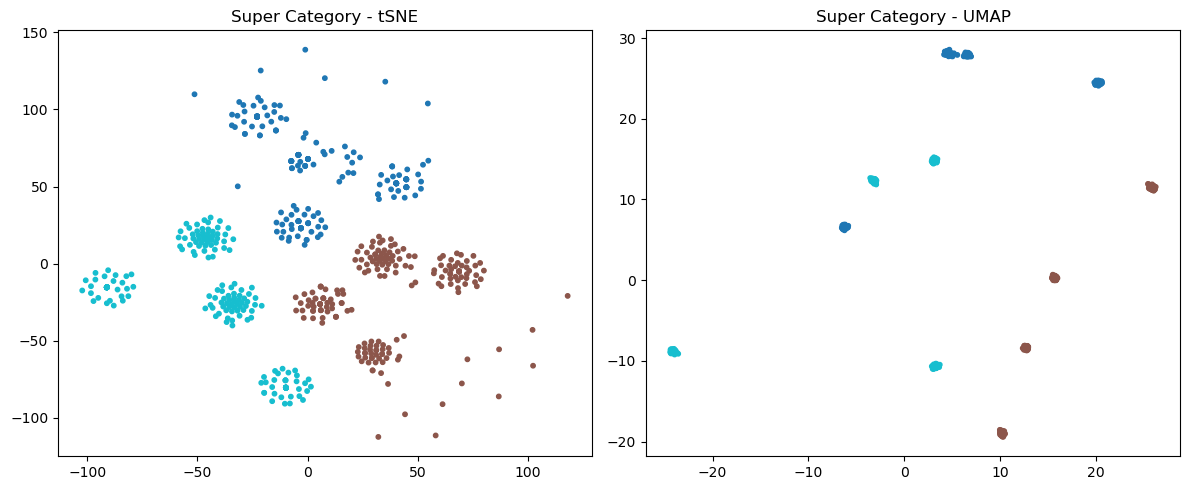

/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


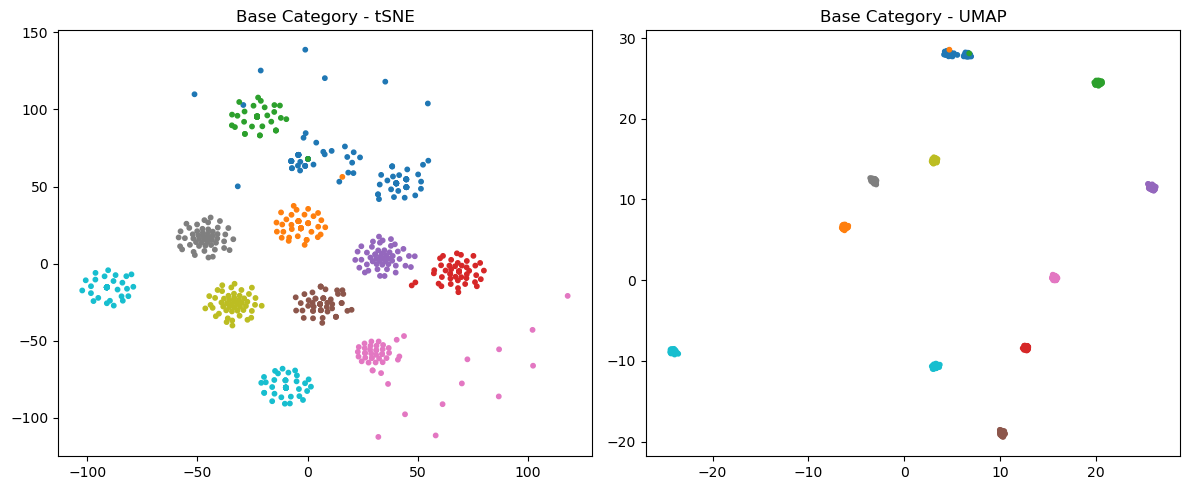

In [10]:
def visualize(X, labels, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    X_tsne = TSNE(n_components=2, perplexity=30, random_state=0).fit_transform(X)
    axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='tab10', s=10)
    axes[0].set_title(f"{title} - tSNE")

    X_umap = umap.UMAP(random_state=0).fit_transform(X)
    axes[1].scatter(X_umap[:, 0], X_umap[:, 1], c=labels, cmap='tab10', s=10)
    axes[1].set_title(f"{title} - UMAP")
    plt.tight_layout()
    plt.show()

visualize(X, labels_super, "Super Category")
visualize(X, labels_base, "Base Category")

In [11]:
import numpy as np
import torch

# Parameters
num_super = 3
num_base_per_super = 4
num_bases = num_super * num_base_per_super
num_features = 36
samples_per_base = 50

torch.manual_seed(42)
np.random.seed(42)

# 1. Super-category prototypes: random binary vectors with max separation
# Generate all 2^36 binary codes is not feasible, so we do random sampling and enforce separation
def generate_separated_binary_prototypes(num, num_features, min_hamming_dist=10):
    prototypes = []
    while len(prototypes) < num:
        candidate = torch.randint(0, 2, (num_features,), dtype=torch.float)
        if all((candidate != p).sum() >= min_hamming_dist for p in prototypes):
            prototypes.append(candidate)
    return torch.stack(prototypes)

super_prototypes = generate_separated_binary_prototypes(num_super, num_features, min_hamming_dist=12)

# 2. Base-category prototypes: small perturbation of super prototypes
base_prototypes = []
base_to_super = []

for super_id in range(num_super):
    super_proto = super_prototypes[super_id]
    for _ in range(num_base_per_super):
        base_proto = super_proto.clone()
        flip_mask = torch.rand(num_features) < 0.1  # 10% bit flip
        base_proto[flip_mask] = 1 - base_proto[flip_mask]
        base_prototypes.append(base_proto)
        base_to_super.append(super_id)

base_prototypes = torch.stack(base_prototypes)
base_to_super = torch.tensor(base_to_super)

# 3. Sample generation: very small noise from base prototype
X, y = [], []
labels_base = []
labels_super = []

for base_id, base_proto in enumerate(base_prototypes):
    super_id = base_to_super[base_id].item()
    for _ in range(samples_per_base):
        sample = base_proto.clone()
        flip_mask = torch.rand(num_features) < 0.02  # 2% noise
        sample[flip_mask] = 1 - sample[flip_mask]

        X.append(sample.numpy())
        y.append(base_id)
        labels_base.append(base_id)
        labels_super.append(super_id)

X = np.array(X)
y = np.array(y)
labels_base = np.array(labels_base)
labels_super = np.array(labels_super)


/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


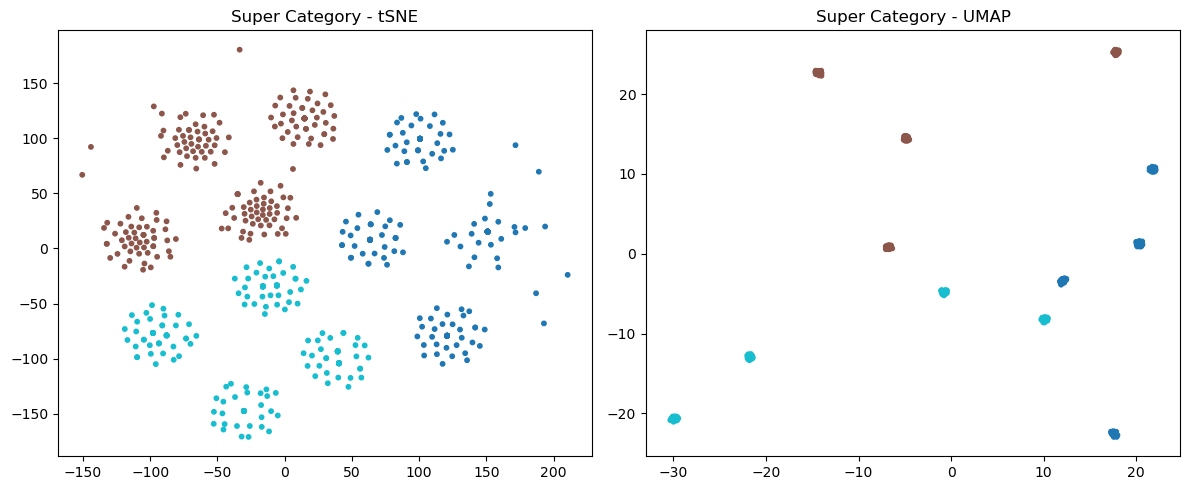

/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


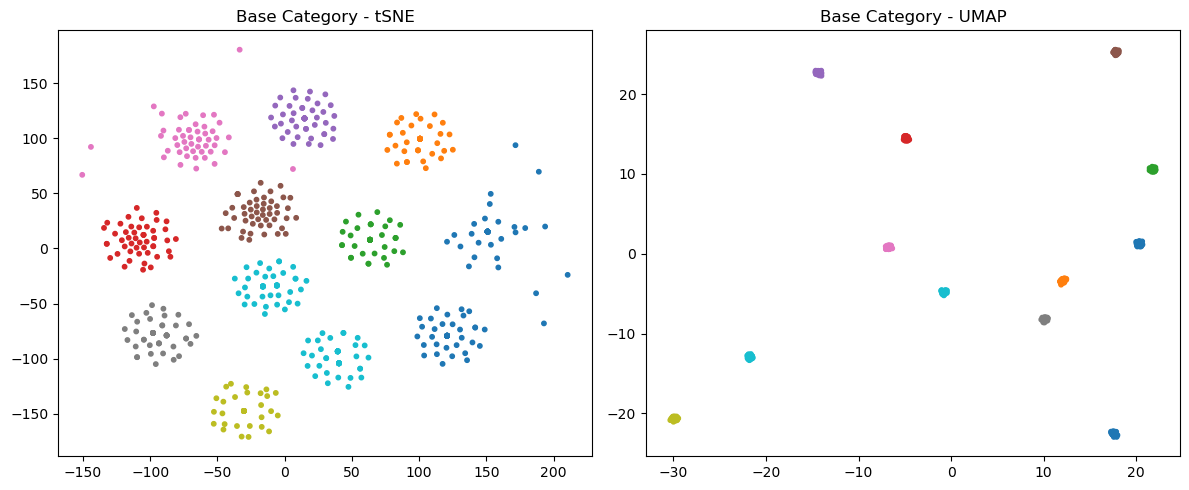

In [12]:
def visualize(X, labels, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    X_tsne = TSNE(n_components=2, perplexity=30, random_state=0).fit_transform(X)
    axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='tab10', s=10)
    axes[0].set_title(f"{title} - tSNE")

    X_umap = umap.UMAP(random_state=0).fit_transform(X)
    axes[1].scatter(X_umap[:, 0], X_umap[:, 1], c=labels, cmap='tab10', s=10)
    axes[1].set_title(f"{title} - UMAP")
    plt.tight_layout()
    plt.show()

visualize(X, labels_super, "Super Category")
visualize(X, labels_base, "Base Category")

In [13]:
import numpy as np
import torch

# Parameters
num_super = 3
num_base_per_super = 4
num_bases = num_super * num_base_per_super
num_features = 36
samples_per_base = 50

torch.manual_seed(42)
np.random.seed(42)

# 1. Divide features into non-overlapping regions per super category
# e.g. Super 0 → bits 0–11, Super 1 → bits 12–23, Super 2 → bits 24–35
bits_per_super = num_features // num_super
super_bit_indices = [list(range(i * bits_per_super, (i + 1) * bits_per_super)) for i in range(num_super)]

# 2. Create super-category prototypes (set 1s in its bit region only)
super_prototypes = []
for indices in super_bit_indices:
    proto = torch.zeros(num_features)
    proto[indices] = torch.randint(0, 2, (len(indices),)).float()
    super_prototypes.append(proto)
super_prototypes = torch.stack(super_prototypes)

# 3. Create base-category prototypes by flipping bits ONLY in super's region
base_prototypes = []
base_to_super = []

for super_id in range(num_super):
    super_proto = super_prototypes[super_id]
    indices = super_bit_indices[super_id]
    
    for _ in range(num_base_per_super):
        base_proto = super_proto.clone()
        flip_mask = torch.zeros(num_features).bool()
        
        # Flip 10% of bits ONLY within the super's region
        flip_in_region = torch.rand(len(indices)) < 0.1
        flip_mask[torch.tensor(indices)] = flip_in_region
        
        base_proto[flip_mask] = 1 - base_proto[flip_mask]
        base_prototypes.append(base_proto)
        base_to_super.append(super_id)

base_prototypes = torch.stack(base_prototypes)
base_to_super = torch.tensor(base_to_super)

# 4. Generate samples by flipping 2% bits (local noise)
X, y = [], []
labels_base = []
labels_super = []

for base_id, base_proto in enumerate(base_prototypes):
    super_id = base_to_super[base_id].item()
    for _ in range(samples_per_base):
        sample = base_proto.clone()
        flip_mask = torch.rand(num_features) < 0.02
        sample[flip_mask] = 1 - sample[flip_mask]

        X.append(sample.numpy())
        y.append(base_id)
        labels_base.append(base_id)
        labels_super.append(super_id)

X = np.array(X)
y = np.array(y)
labels_base = np.array(labels_base)
labels_super = np.array(labels_super)


/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for hamming distance metric; inverse_transform will be unavailable
  warn(
/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


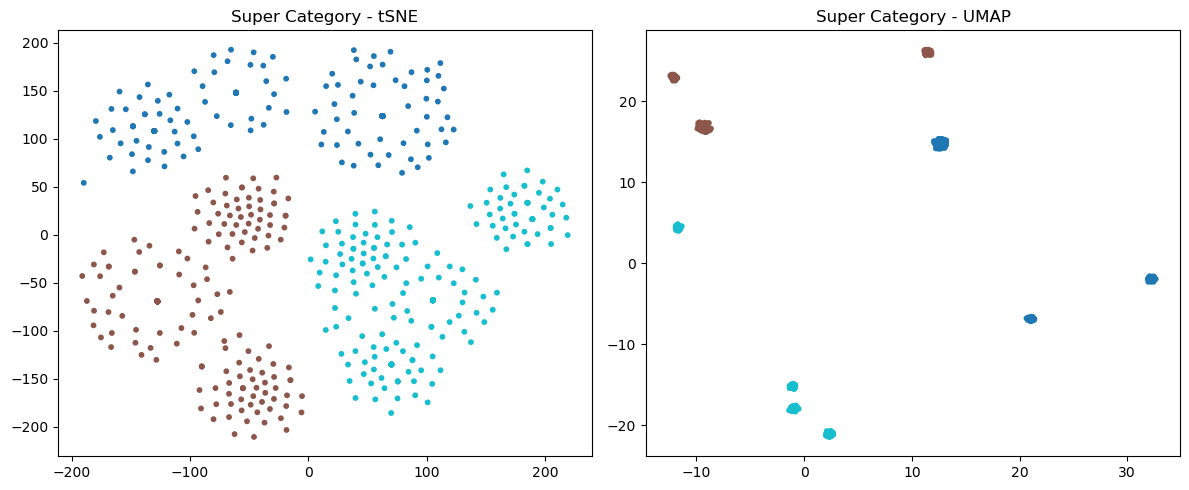

/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for hamming distance metric; inverse_transform will be unavailable
  warn(
/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


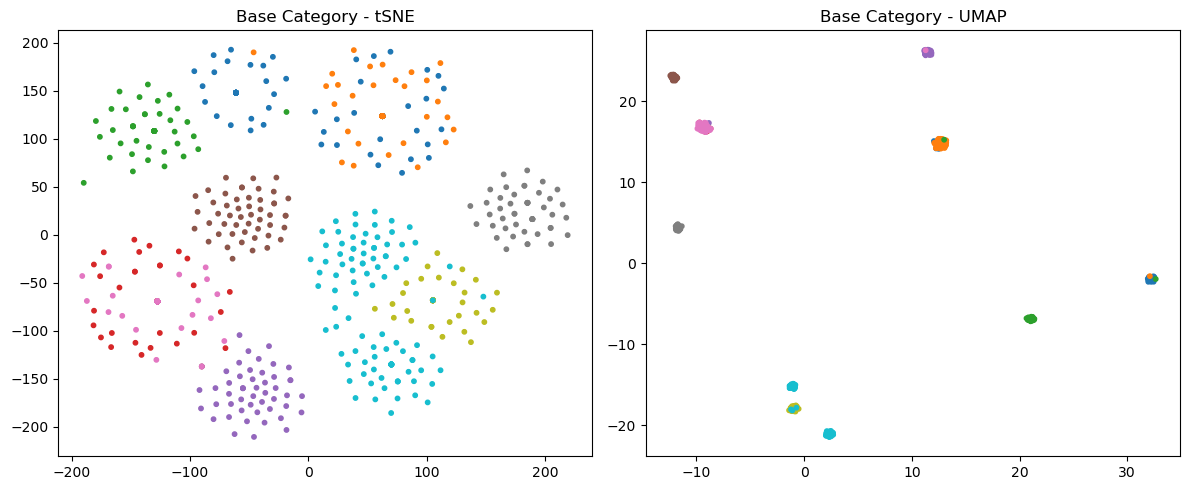

In [14]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap

def visualize(X, labels, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    X_tsne = TSNE(n_components=2, perplexity=50, metric='hamming', random_state=0).fit_transform(X)
    axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='tab10', s=10)
    axes[0].set_title(f"{title} - tSNE")

    X_umap = umap.UMAP(metric='hamming', random_state=0).fit_transform(X)
    axes[1].scatter(X_umap[:, 0], X_umap[:, 1], c=labels, cmap='tab10', s=10)
    axes[1].set_title(f"{title} - UMAP")

    plt.tight_layout()
    plt.show()

visualize(X, labels_super, "Super Category")
visualize(X, labels_base, "Base Category")


In [15]:
import numpy as np
import torch

# Parameters
num_super = 3
num_base_per_super = 4
num_bases = num_super * num_base_per_super
num_features = 36
samples_per_base = 50

torch.manual_seed(42)
np.random.seed(42)

bits_per_super = num_features // num_super
super_bit_indices = [list(range(i * bits_per_super, (i + 1) * bits_per_super)) for i in range(num_super)]

# Super-category prototypes: sparse or binary codes
super_prototypes = []
for indices in super_bit_indices:
    proto = torch.zeros(num_features)
    proto[indices] = torch.randint(0, 2, (len(indices),)).float()
    super_prototypes.append(proto)
super_prototypes = torch.stack(super_prototypes)

# Base-category prototypes: offsets from super prototype (within same subspace)
base_prototypes = []
base_to_super = []

for super_id in range(num_super):
    super_proto = super_prototypes[super_id]
    indices = super_bit_indices[super_id]
    
    for _ in range(num_base_per_super):
        base_proto = super_proto.clone()
        
        # Add small offset in the subspace (bit flipping 10%)
        flip_mask = torch.rand(len(indices)) < 0.1
        flip_indices = torch.tensor(indices)[flip_mask]
        base_proto[flip_indices] = 1 - base_proto[flip_indices]
        
        base_prototypes.append(base_proto)
        base_to_super.append(super_id)

base_prototypes = torch.stack(base_prototypes)
base_to_super = torch.tensor(base_to_super)

# Generate samples around base prototypes with very slight noise
X, y = [], []
labels_base = []
labels_super = []

for base_id, base_proto in enumerate(base_prototypes):
    super_id = base_to_super[base_id].item()
    
    for _ in range(samples_per_base):
        sample = base_proto.clone()
        flip_mask = torch.rand(num_features) < 0.02
        sample[flip_mask] = 1 - sample[flip_mask]

        X.append(sample.numpy())
        y.append(base_id)
        labels_base.append(base_id)
        labels_super.append(super_id)

X = np.array(X)
labels_base = np.array(labels_base)
labels_super = np.array(labels_super)


/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for hamming distance metric; inverse_transform will be unavailable
  warn(
/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


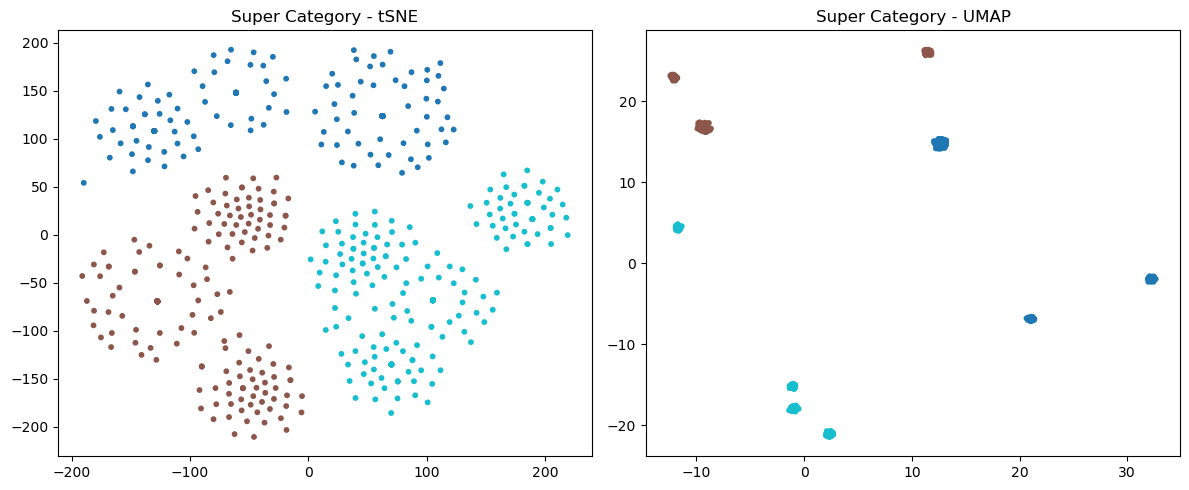

/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for hamming distance metric; inverse_transform will be unavailable
  warn(
/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


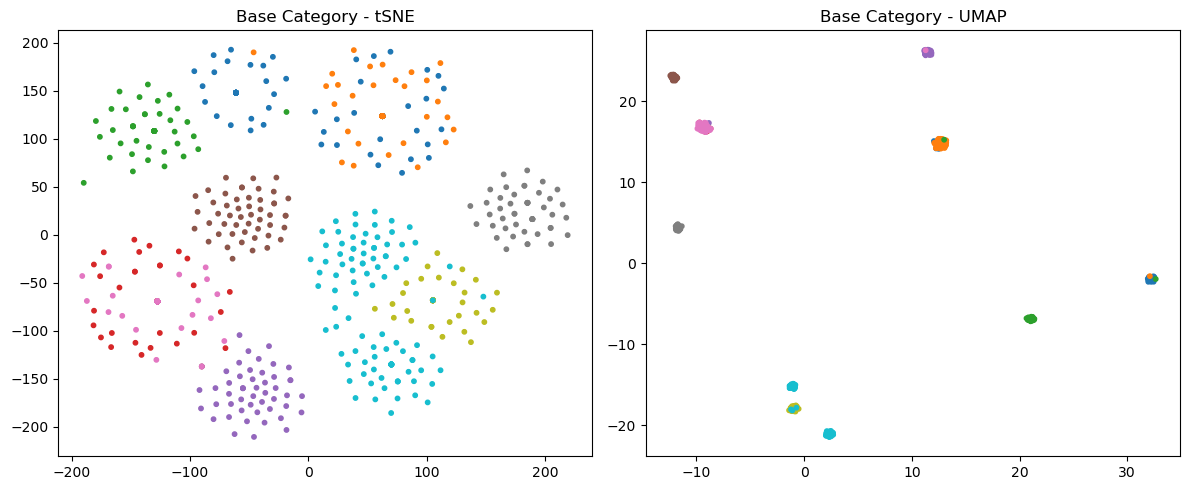

In [16]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap

def visualize(X, labels, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    X_tsne = TSNE(n_components=2, perplexity=50, metric='hamming', random_state=0).fit_transform(X)
    axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='tab10', s=10)
    axes[0].set_title(f"{title} - tSNE")

    X_umap = umap.UMAP(metric='hamming', random_state=0).fit_transform(X)
    axes[1].scatter(X_umap[:, 0], X_umap[:, 1], c=labels, cmap='tab10', s=10)
    axes[1].set_title(f"{title} - UMAP")

    plt.tight_layout()
    plt.show()

visualize(X, labels_super, "Super Category")
visualize(X, labels_base, "Base Category")


In [17]:
import numpy as np
import torch

# Config
num_super = 3
num_base_per_super = 4
num_features = 36
samples_per_base = 50

total_base = num_super * num_base_per_super
torch.manual_seed(42)

# Step 1: Super-category prototypes: spread in ℝ^n
super_prototypes = torch.randn(num_super, num_features) * 10.0  # very spread out

# Step 2: Base-category prototypes near their super center
base_prototypes = []
base_to_super = []

for super_id in range(num_super):
    super_center = super_prototypes[super_id]
    
    for _ in range(num_base_per_super):
        offset = torch.randn(num_features) * 1.0  # tighter around super center
        base_proto = super_center + offset
        base_prototypes.append(base_proto)
        base_to_super.append(super_id)

base_prototypes = torch.stack(base_prototypes)
base_to_super = torch.tensor(base_to_super)

# Step 3: Generate samples around base prototype with small noise
X = []
labels_base = []
labels_super = []

for base_id, base_proto in enumerate(base_prototypes):
    super_id = base_to_super[base_id].item()
    
    for _ in range(samples_per_base):
        noise = torch.randn(num_features) * 0.5  # small local noise
        sample = base_proto + noise

        X.append(sample.numpy())
        labels_base.append(base_id)
        labels_super.append(super_id)

X = np.array(X)
labels_base = np.array(labels_base)
labels_super = np.array(labels_super)


/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


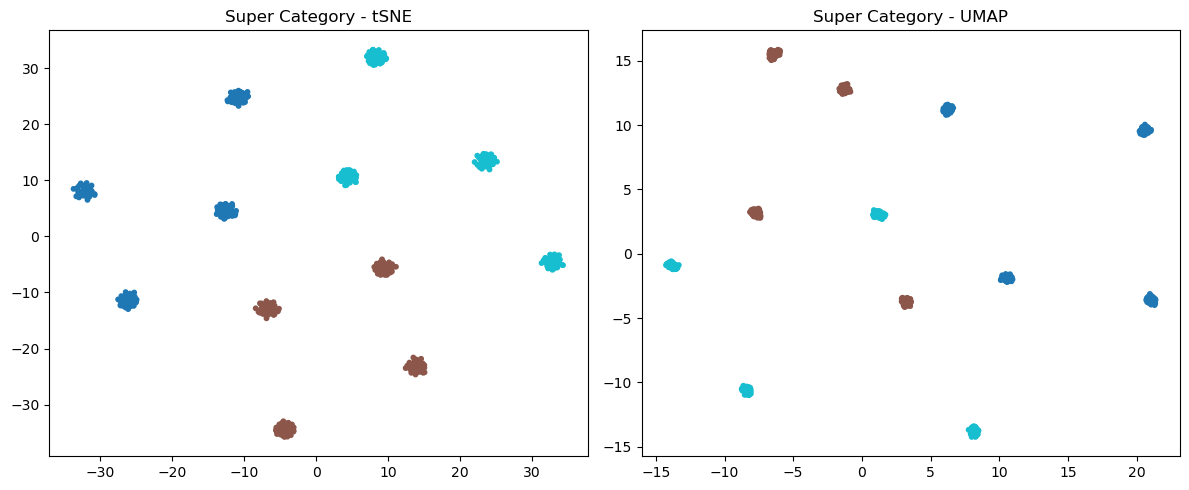

/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


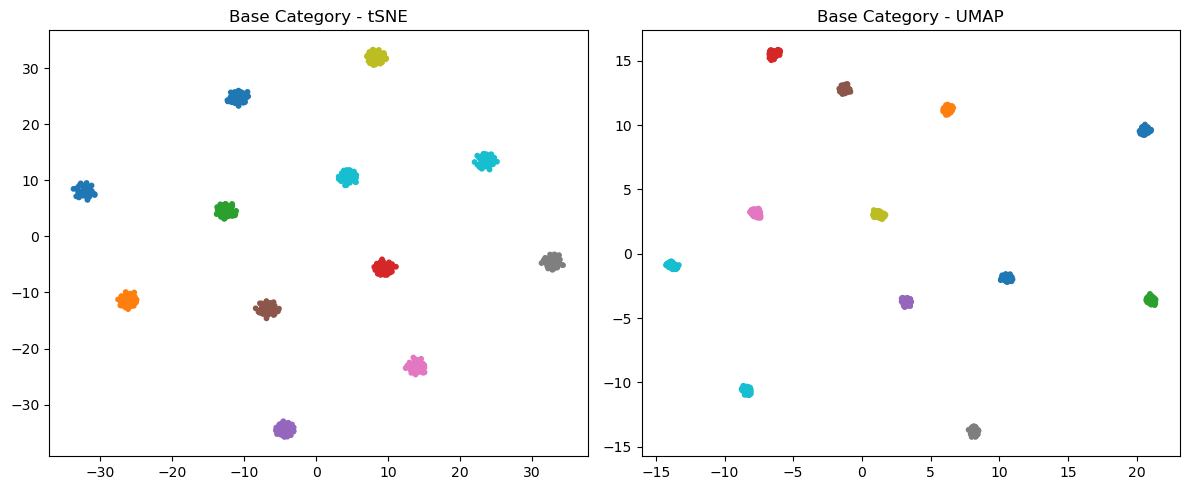

In [18]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap

def visualize(X, labels, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    X_tsne = TSNE(n_components=2, perplexity=30, metric='euclidean', random_state=0).fit_transform(X)
    axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='tab10', s=10)
    axes[0].set_title(f"{title} - tSNE")

    X_umap = umap.UMAP(metric='euclidean', random_state=0).fit_transform(X)
    axes[1].scatter(X_umap[:, 0], X_umap[:, 1], c=labels, cmap='tab10', s=10)
    axes[1].set_title(f"{title} - UMAP")

    plt.tight_layout()
    plt.show()

visualize(X, labels_super, "Super Category")
visualize(X, labels_base, "Base Category")


In [21]:
import numpy as np
import torch

# Config
num_super = 4
num_base_per_super = 4
num_features = 36
samples_per_base = 50
torch.manual_seed(42)

# Step 1: Super-category centers — well-separated
super_prototypes = torch.randn(num_super, num_features) * 20.0  # very spread

base_prototypes = []
base_to_super = []

for super_id in range(num_super):
    super_center = super_prototypes[super_id]

    # Step 2: Local orthonormal basis for base prototypes within each super-category
    local_basis = torch.linalg.qr(torch.randn(num_features, num_base_per_super)).Q.T  # (num_base, feat)
    
    for i in range(num_base_per_super):
        # Project local direction + small offset from super center
        offset = local_basis[i] * 2.0  # tighter subspace around super center
        base_proto = super_center + offset

        base_prototypes.append(base_proto)
        base_to_super.append(super_id)

base_prototypes = torch.stack(base_prototypes)
base_to_super = torch.tensor(base_to_super)

# Step 3: Sample generation
X = []
labels_base = []
labels_super = []

for base_id, base_proto in enumerate(base_prototypes):
    super_id = base_to_super[base_id].item()
    
    for _ in range(samples_per_base):
        noise = torch.randn(num_features) * 0.5  # local noise around base proto
        sample = base_proto + noise

        X.append(sample.numpy())
        labels_base.append(base_id)
        labels_super.append(super_id)

X = np.array(X)
labels_base = np.array(labels_base)
labels_super = np.array(labels_super)


/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


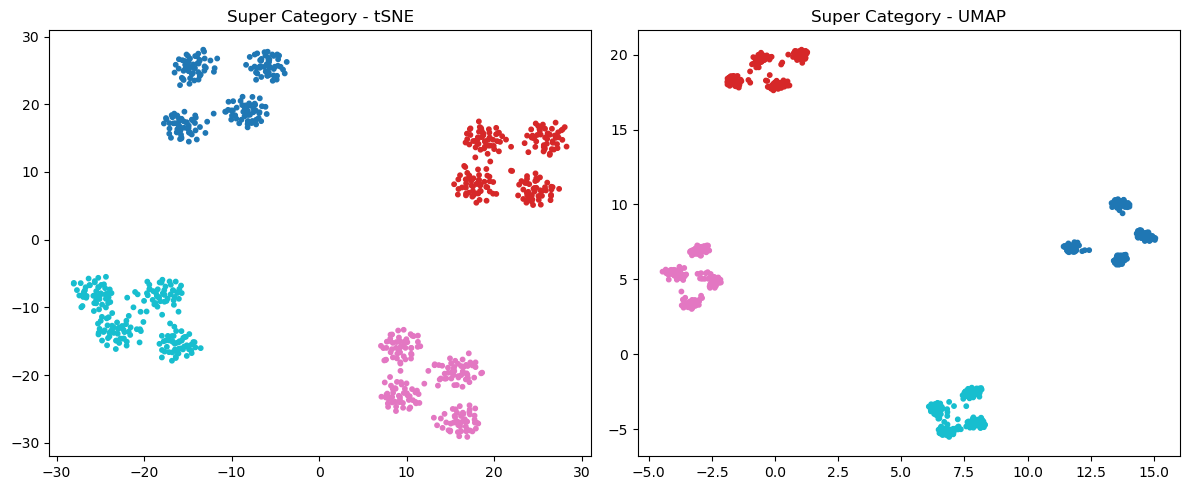

/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


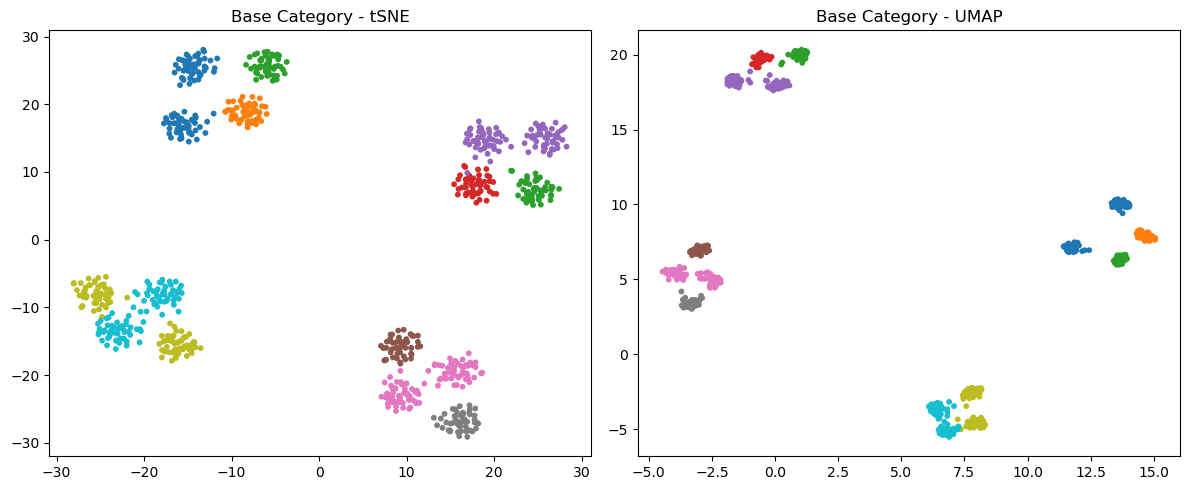

In [22]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap

def visualize(X, labels, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    X_tsne = TSNE(n_components=2, perplexity=30, metric='euclidean', random_state=0).fit_transform(X)
    axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='tab10', s=10)
    axes[0].set_title(f"{title} - tSNE")

    X_umap = umap.UMAP(metric='euclidean', random_state=0).fit_transform(X)
    axes[1].scatter(X_umap[:, 0], X_umap[:, 1], c=labels, cmap='tab10', s=10)
    axes[1].set_title(f"{title} - UMAP")

    plt.tight_layout()
    plt.show()

visualize(X, labels_super, "Super Category")
visualize(X, labels_base, "Base Category")
